In [ ]:
import os
import sys
root_path = os.path.abspath('./..')
sys.path.insert(0, root_path)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import hiddensc
from hiddensc import utils, vis
import scanpy as sc
import scvi
import anndata
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.simplefilter("ignore", category=ConvergenceWarning)
from scipy.sparse import issparse
from functools import reduce

from SpatialPeeler import helpers as hlps
from SpatialPeeler import case_prediction as cpred
from SpatialPeeler import plotting as plot
from SpatialPeeler import gene_identification as gid
from sklearn.cluster import KMeans
import statsmodels.api as sm
from scipy.special import logit
import pickle
RAND_SEED = 28
CASE_COND = 1
np.random.seed(RAND_SEED)
utils.set_random_seed(utils.RANDOM_SEED)
utils.print_module_versions([sc, anndata, scvi, hiddensc])
vis.visual_settings()

CONDITION_TAG = 'condition' # 'disease'
CONTROL_TAG = 'CONTROL' #'normal'
CASE_TAG = 'PSC' #'primary sclerosing cholangitis'


In [ ]:
### the latest version of the code learning to this pkl file is 2.5.remyelin_spatialpeeler_Fclust.py
RAND_SEED = 28
CASE_COND = 1
np.random.seed(RAND_SEED)
CASE_COND_NAME = 'LPC'

#results_filename = 'remyelin_nmf30_hidden_logistic_Fclust_t3_7.pkl'
#results_filename = 'remyelin_nmf30_hidden_logistic_Fclust_t3_7_PreprocV2.pkl'
#results_filename = 'remyelin_nmf30_hidden_logistic_t3_7_PreprocV2_noFclust.pkl'
#results_filename = 'remyelin_nmf30_hidden_logistic_zeroThr_Fclust_t7_PreprocV2.pkl'
#results_filename = 'remyelin_nmf30_hidden_logistic_zeroThr_Fclust_t18_PreprocV2.pkl'
#results_filename = 'remyelin_nmf30_hidden_logistic_zeroThr_Fclust_t3_PreprocV2.pkl'
results_filename = 'Results/remyelin_nmf30_hidden_logistic_zeroThr_Fclust_t3_PreprocV2_t12.18control_samplewise.pkl'
with open(results_filename, 'rb') as f:
    results = pickle.load(f)


In [ ]:
outp = '/lustre/scratch126/gengen/teams_v2/marks/dp31/SpatialPeeler/Data/Remyelin_Slide-seq/Remyelin_NMF_30_uncropped_t3_PreprocV2_t12.18control_samplewise.h5ad'
adata = sc.read_h5ad(outp)

adata.obs['binary_label'] = adata.obs['Condition'].apply(lambda x: 1 if x == 'LPC' else 0)
adata.obs['status'] = adata.obs['binary_label'].astype(int).values
sample_ids = adata.obs['sample_id'].unique().tolist()

cluster_mask_dict = {}
factor_idx = 0
print(f"Factor {factor_idx+1}")

def get_num_sig_de(de_results, fdr_threshold=0.05, logfc_threshold=0.1):
        sig_de = de_results[
            (de_results['pvals_adj'] < fdr_threshold) &
            (np.abs(de_results['logfoldchanges']) > logfc_threshold)
        ]
        return sig_de.shape[0]

########################################################
############## IGNORE THIS PART, JUST FOR REMEMBERING OLD ANALYSIS
### new processing data
t18_gof_v2 = [4, 27, 24, 10, 8]
t7_gof_v2 = [14, 28, 11, 6, 0, 18, 21]
t3_7_gof_v2 = [3, 4, 16, 8, 0, 1, 17, 15]
t3_7_gof_v2_noFclust = [4, 13, 16, 3, 17, 29, 26, 0, 23]
#######
### old processing data
t3_7_gof = [9, 21, 18, 11, 1, 2, 5, 23]
t18_gof = [9, 2, 12, 18]
t18_lof = [3, 6, 19]
t7_gof = [0, 12, 20, 2]
t7_lof = [10, 18, 7]
t18_gof_v2 = [4, 27, 24, 10, 8]
########################################################

t3_gof_control12_18 = [8, 13, 16, 28, 0, 4, 21, 2, 11]
t3_gof_v2 = t3_gof_control12_18[0:4]

factor_idx = t3_gof_v2[0]


Factor 1


Factor 9


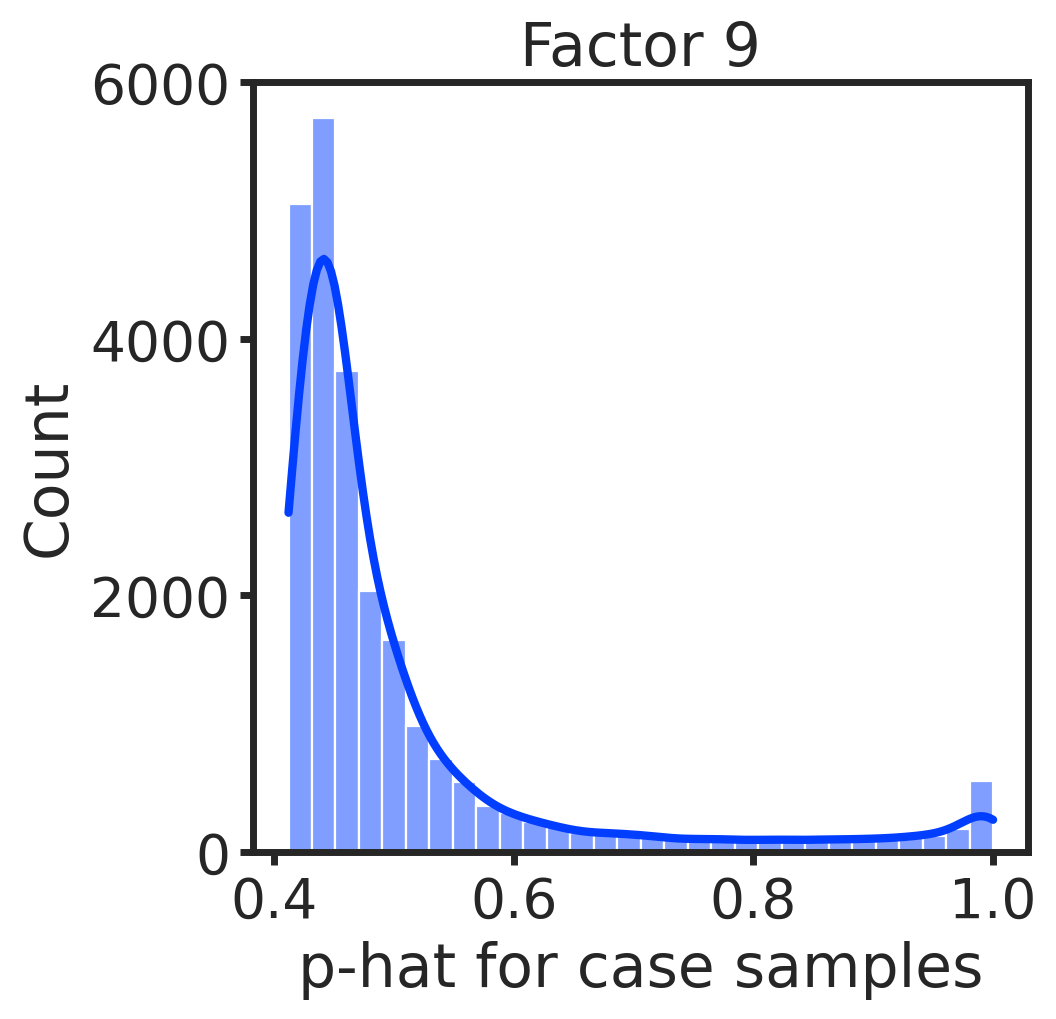

True
Centroids: [0.86456273 0.46697032]
Binarization Threshold: 0.6657665224484479
object
phat_cluster_factor9
control_0    25240
case_0       21682
case_1        2375
control_1      223
Name: count, dtype: int64


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000100162', 'ENSMUSG00000110375', 'ENSMUSG00000098243', 'ENSMUSG00000103428']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000050708  70.555           8.895  0.000      0.000      Ftl1
1   ENSMUSG00000007891  58.848           7.408  0.000      0.000      Ctsd
2   ENSMUSG00000049775  55.606           5.558  0.000      0.000    Tmsb4x
3   ENSMUSG00000021939  49.975           5.658  0.000      0.000      Ctsb
4   ENSMUSG00000029304  36.004           8.623  0.000      0.000      Spp1
5   ENSMUSG00000021665  35.913           4.555  0.000      0.000      Hexb
6   ENSMUSG00000038642  34.743           4.480  0.000      0.000      Ctss
7   ENSMUSG00000025351  33.344           3.368  0.000      0.000      Cd63
8   ENSMUSG00000036905  31.600           4.775  0.000      0.000      C1qb
9   ENSMUSG00000016256  30.684           5.166  0.000      0.000      Ctsz
10  ENSMUSG00000002985  28.649           4.122  0.000      0.000      Apoe
11  ENSMUSG00000050335  28.397           6.436  0.000      0.000    Lgals3
12  ENSMUSG00000034708  2

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000100162', 'ENSMUSG00000098243', 'ENSMUSG00000110375', 'ENSMUSG00000103428']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000050708  72.531           8.897  0.000      0.000      Ftl1
1   ENSMUSG00000007891  61.163           7.636  0.000      0.000      Ctsd
2   ENSMUSG00000049775  55.830           5.398  0.000      0.000    Tmsb4x
3   ENSMUSG00000021939  51.157           5.620  0.000      0.000      Ctsb
4   ENSMUSG00000029304  37.172           9.075  0.000      0.000      Spp1
5   ENSMUSG00000021665  37.151           4.624  0.000      0.000      Hexb
6   ENSMUSG00000038642  35.630           4.421  0.000      0.000      Ctss
7   ENSMUSG00000025351  34.236           3.355  0.000      0.000      Cd63
8   ENSMUSG00000036905  32.708           4.927  0.000      0.000      C1qb
9   ENSMUSG00000016256  31.722           5.312  0.000      0.000      Ctsz
10  ENSMUSG00000119584  30.260          26.967  0.000      0.000     Rn18s
11  ENSMUSG00000050335  29.462           7.210  0.000      0.000    Lgals3
12  ENSMUSG00000026728  2

...

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000119584  72.454          13.560  0.000      0.000     Rn18s
1   ENSMUSG00000022748  21.509           1.131  0.000      0.000     Cmss1
2   ENSMUSG00000047454  19.377           0.948  0.000      0.000      Gphn
3   ENSMUSG00000039145  18.417           0.678  0.000      0.000    Camk1d
4   ENSMUSG00000035202  16.243           0.736  0.000      0.000     Lars2
5   ENSMUSG00000113136   8.523           0.638  0.000      0.000   Gm19951
6   ENSMUSG00000061080   8.229           1.107  0.000      0.000     Lsamp
7   ENSMUSG00000092341   7.569           2.104  0.000      0.000    Malat1
8   ENSMUSG00000021268   7.479           0.898  0.000      0.000      Meg3
9   ENSMUSG00000007891   7.159           0.514  0.000      0.000      Ctsd
10  ENSMUSG00000052727   6.900           0.500  0.000      0.000     Map1b
11  ENSMUSG00000096054   6.597           0.765  0.000      0.000     Syne1
12  ENSMUSG00000026728   

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000110375', 'ENSMUSG00000100162']


-----------------------------------
Control1 vs Control0
                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000049775  21.628           7.827  0.000      0.000    Tmsb4x
1   ENSMUSG00000050708  12.925           3.167  0.000      0.000      Ftl1
2   ENSMUSG00000092341  12.293           8.713  0.000      0.000    Malat1
3   ENSMUSG00000036438  11.823           5.119  0.000      0.000     Calm2
4   ENSMUSG00000119584  11.687          10.767  0.000      0.000     Rn18s
5   ENSMUSG00000053477  10.810           3.444  0.000      0.000      Tcf4
6   ENSMUSG00000026576  10.556           3.832  0.000      0.000    Atp1b1
7   ENSMUSG00000028161  10.363           5.824  0.000      0.000    Ppp3ca
8   ENSMUSG00000022708   9.884           3.077  0.000      0.000    Zbtb20
9   ENSMUSG00000033981   9.046           3.253  0.000      0.000     Gria2
10  ENSMUSG00000052727   8.951           2.700  0.000      0.000     Map1b
11  ENSMUSG00000028785   8.917           5.

/tmp/ipykernel_1414540/1374827707.py:349: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparisons, y=sig_de_counts, palette="viridis")


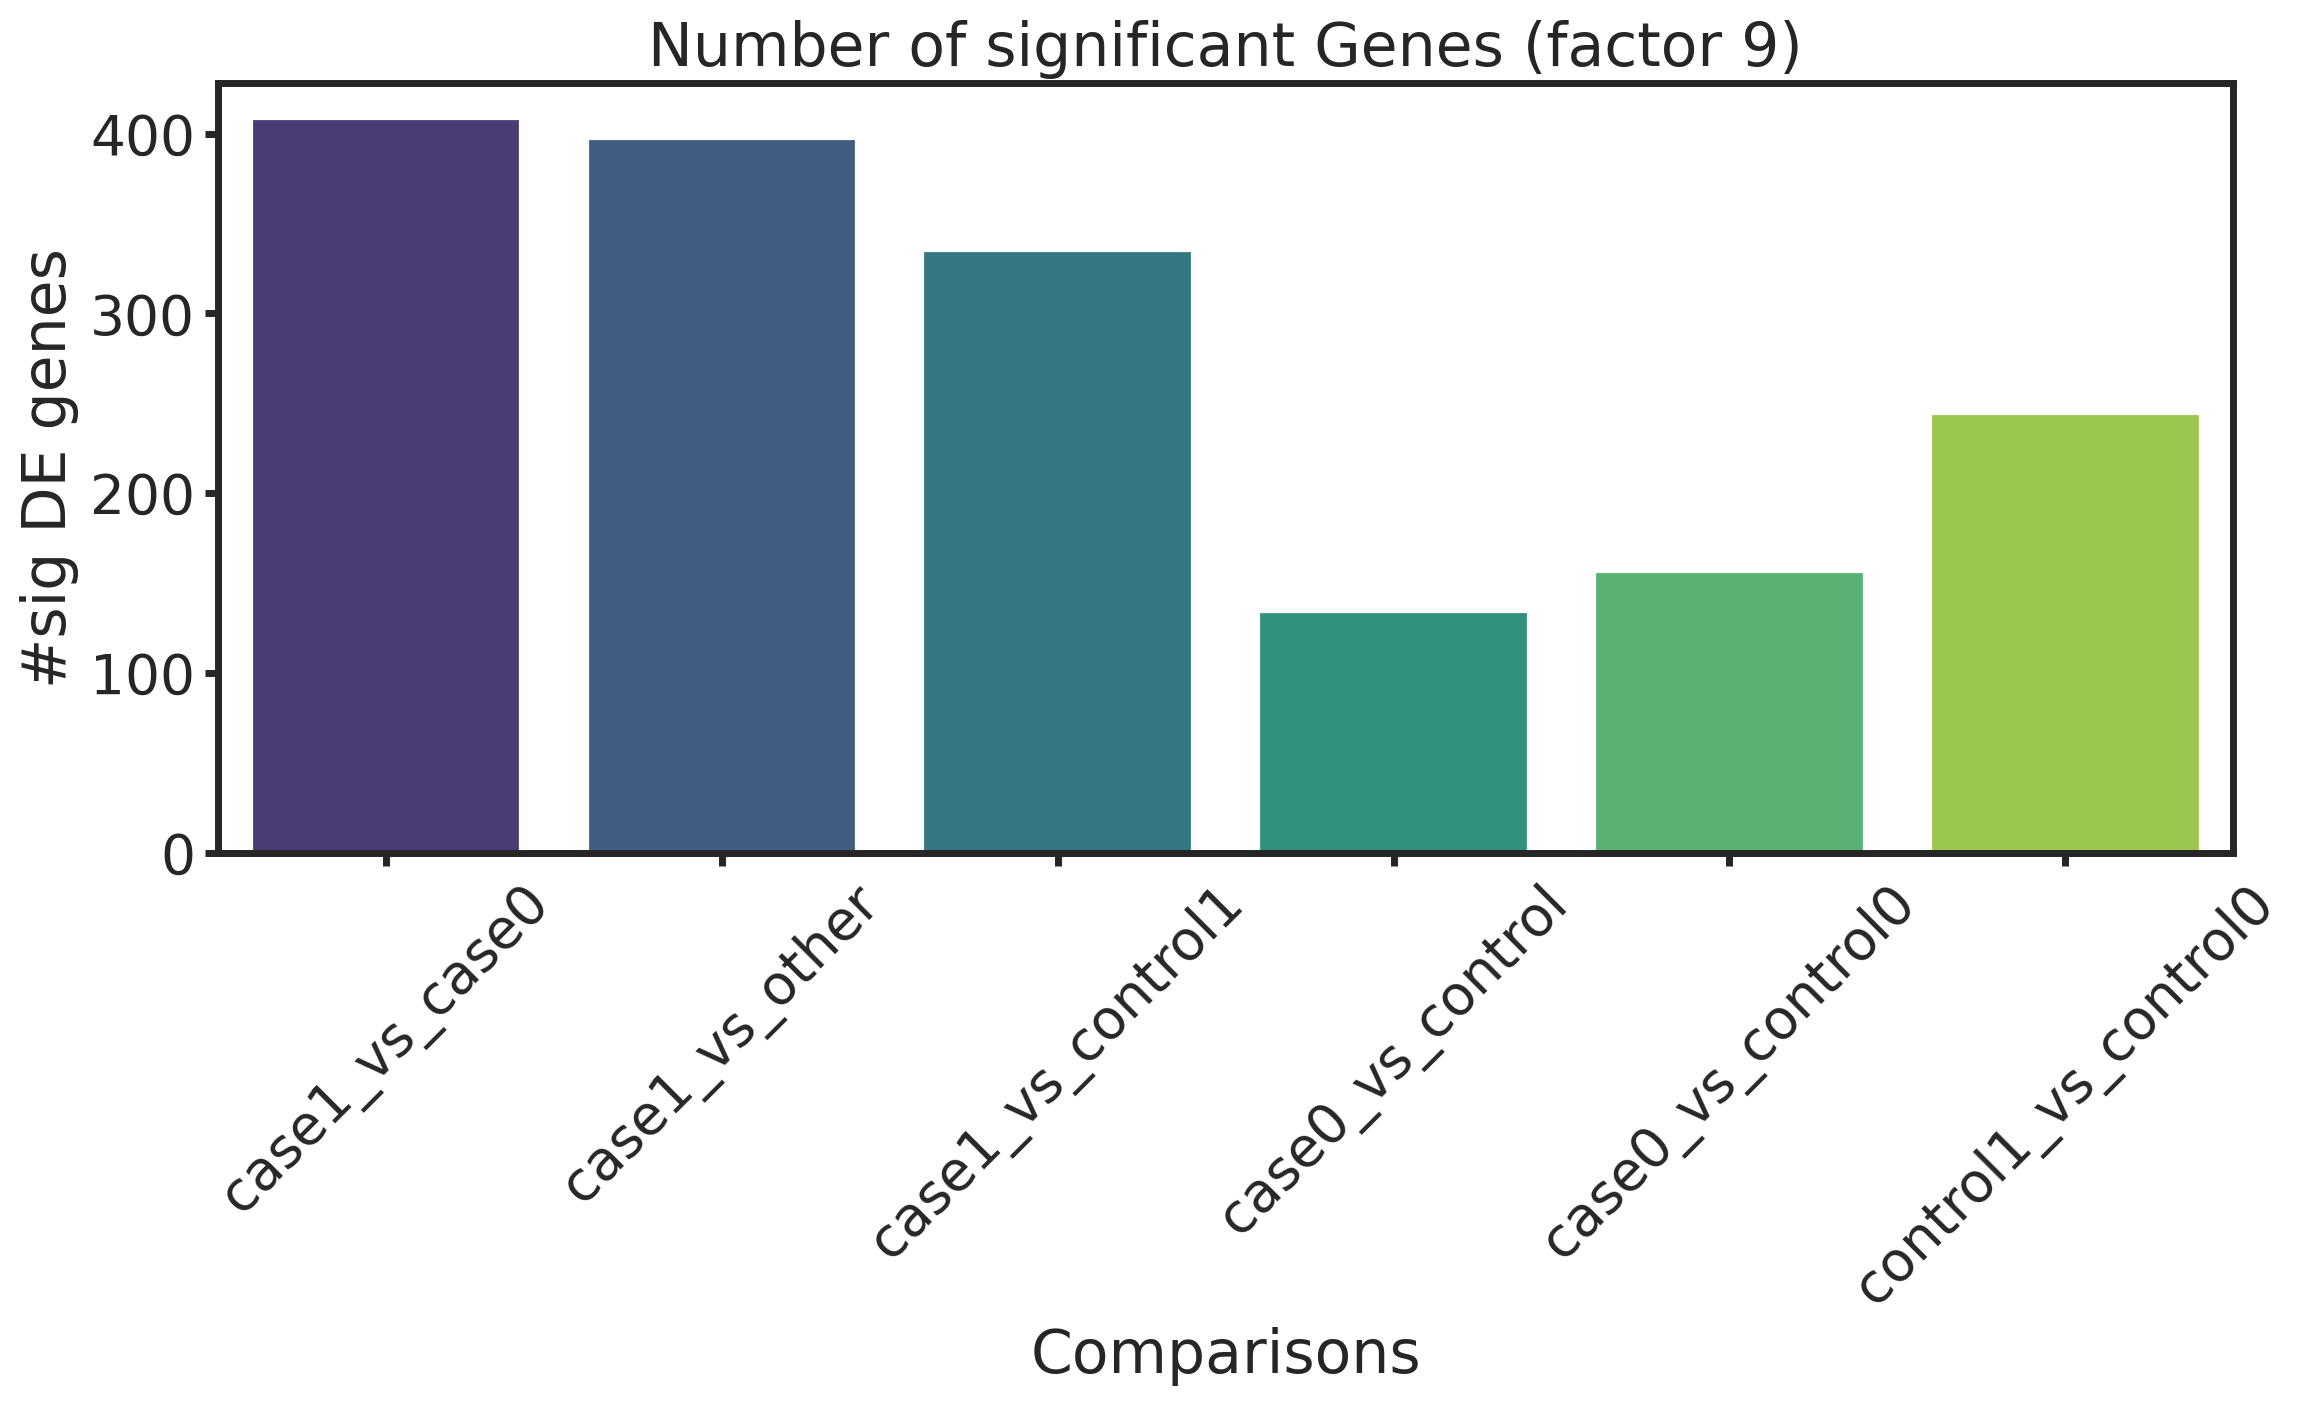

Factor 14


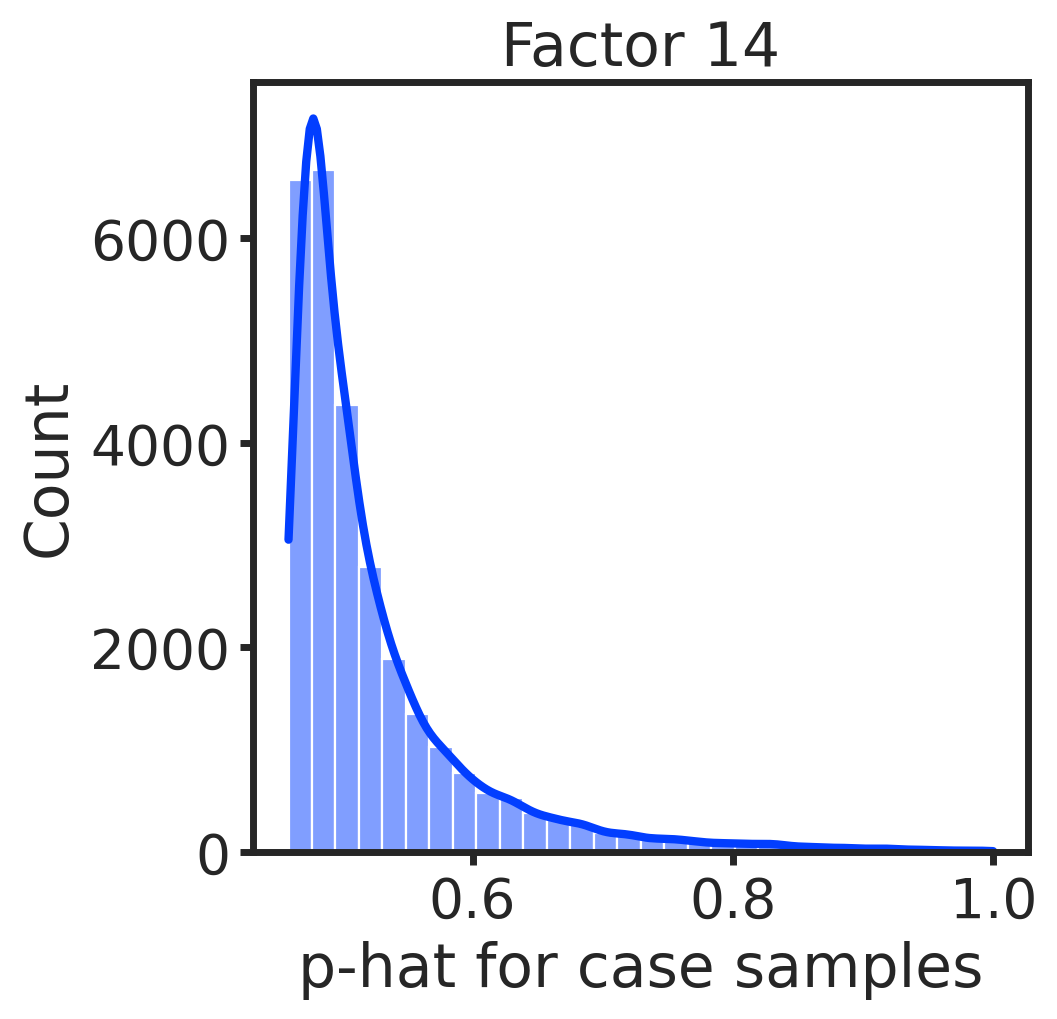

True
Centroids: [0.50024574 0.67857576]
Binarization Threshold: 0.5894107505633579
object
phat_cluster_factor14
control_0    25383
case_0       24860
case_1        3847
control_1     1665
Name: count, dtype: int64


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000035202  92.311           6.777  0.000      0.000     Lars2
1   ENSMUSG00000047454  87.782           6.273  0.000      0.000      Gphn
2   ENSMUSG00000119584  74.883          61.034  0.000      0.000     Rn18s
3   ENSMUSG00000022748  71.277           5.194  0.000      0.000     Cmss1
4   ENSMUSG00000039145  55.225           4.937  0.000      0.000    Camk1d
5   ENSMUSG00000113136  35.766           2.578  0.000      0.000   Gm19951
6   ENSMUSG00000092341  31.991          10.433  0.000      0.000    Malat1
7   ENSMUSG00000052727  24.197           2.257  0.000      0.000     Map1b
8   ENSMUSG00000026576  19.429           1.553  0.000      0.000    Atp1b1
9   ENSMUSG00000096054  17.920           2.235  0.000      0.000     Syne1
10  ENSMUSG00000036438  17.663           1.560  0.000      0.000     Calm2
11  ENSMUSG00000035864  16.721           1.680  0.000      0.000      Syt1
12  ENSMUSG00000064115  1

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000035202  93.310           6.548  0.000      0.000     Lars2
1   ENSMUSG00000047454  90.436           6.259  0.000      0.000      Gphn
2   ENSMUSG00000119584  85.606          66.486  0.000      0.000     Rn18s
3   ENSMUSG00000022748  75.412           5.325  0.000      0.000     Cmss1
4   ENSMUSG00000039145  58.524           4.900  0.000      0.000    Camk1d
5   ENSMUSG00000113136  37.647           2.602  0.000      0.000   Gm19951
6   ENSMUSG00000092341  36.565          11.498  0.000      0.000    Malat1
7   ENSMUSG00000052727  26.119           2.362  0.000      0.000     Map1b
8   ENSMUSG00000096054  19.851           2.446  0.000      0.000     Syne1
9   ENSMUSG00000021268  18.075           2.687  0.000      0.000      Meg3
10  ENSMUSG00000064115  17.019           2.234  0.000      0.000     Cadm2
11  ENSMUSG00000061080  16.889           2.982  0.000      0.000     Lsamp
12  ENSMUSG00000032826  1

...

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000119584  89.004          12.296  0.000      0.000     Rn18s
1   ENSMUSG00000022748  19.622           0.604  0.000      0.000     Cmss1
2   ENSMUSG00000047454  19.149           0.496  0.000      0.000      Gphn
3   ENSMUSG00000039145  17.455           0.474  0.000      0.000    Camk1d
4   ENSMUSG00000092341  14.212           2.379  0.000      0.000    Malat1
5   ENSMUSG00000035202  12.564           0.304  0.000      0.000     Lars2
6   ENSMUSG00000007891   9.186           1.854  0.000      0.000      Ctsd
7   ENSMUSG00000021268   8.131           0.871  0.000      0.000      Meg3
8   ENSMUSG00000061080   7.448           0.949  0.000      0.000     Lsamp
9   ENSMUSG00000028649   6.639           0.719  0.000      0.000     Macf1
10  ENSMUSG00000113136   6.405           0.378  0.000      0.000   Gm19951
11  ENSMUSG00000029088   6.390           1.222  0.000      0.000    Kcnip4
12  ENSMUSG00000052727   

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


-----------------------------------
Control1 vs Control0
                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000035202  64.868           7.741  0.000      0.000     Lars2
1   ENSMUSG00000047454  60.688           5.694  0.000      0.000      Gphn
2   ENSMUSG00000119584  46.088          29.680  0.000      0.000     Rn18s
3   ENSMUSG00000039145  39.046           6.245  0.000      0.000    Camk1d
4   ENSMUSG00000022748  38.058           3.681  0.000      0.000     Cmss1
5   ENSMUSG00000113136  21.068           2.723  0.000      0.000   Gm19951
6   ENSMUSG00000092341  20.266           4.695  0.000      0.000    Malat1
7   ENSMUSG00000036438  15.213           1.980  0.000      0.000     Calm2
8   ENSMUSG00000052727  13.742           1.661  0.000      0.000     Map1b
9   ENSMUSG00000026576  12.727           1.438  0.000      0.000    Atp1b1
10  ENSMUSG00000049775  12.643           1.267  0.000      0.000    Tmsb4x
11  ENSMUSG00000027273  12.094           1.

/tmp/ipykernel_1414540/1374827707.py:349: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparisons, y=sig_de_counts, palette="viridis")


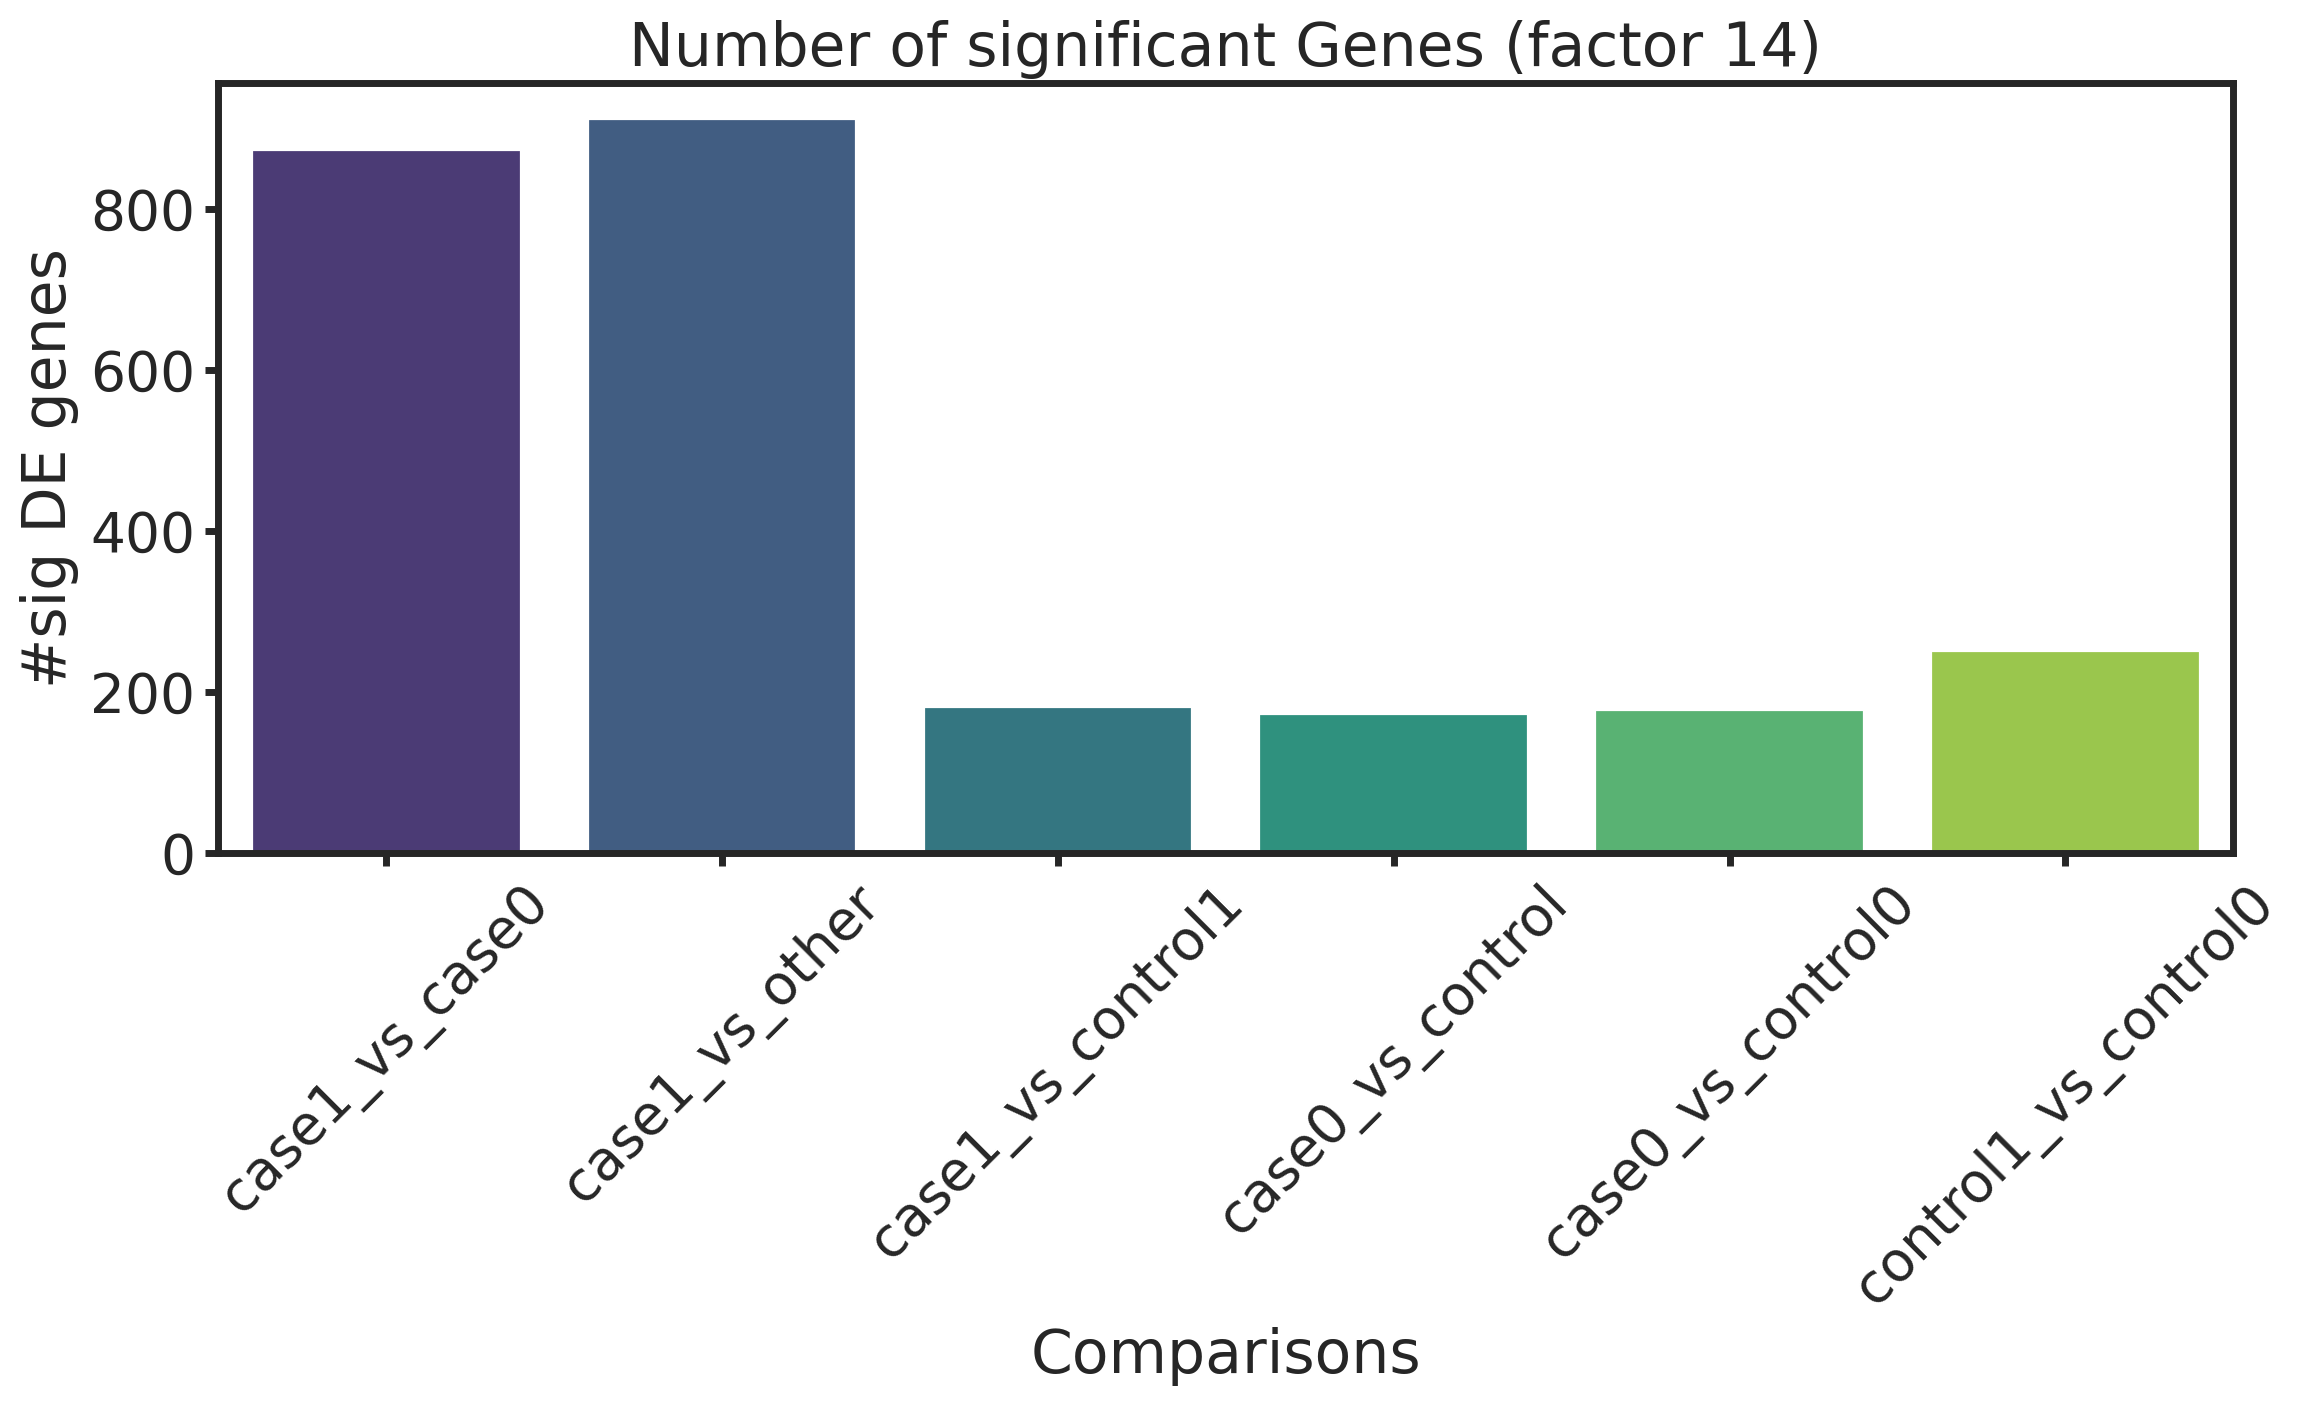

Factor 17


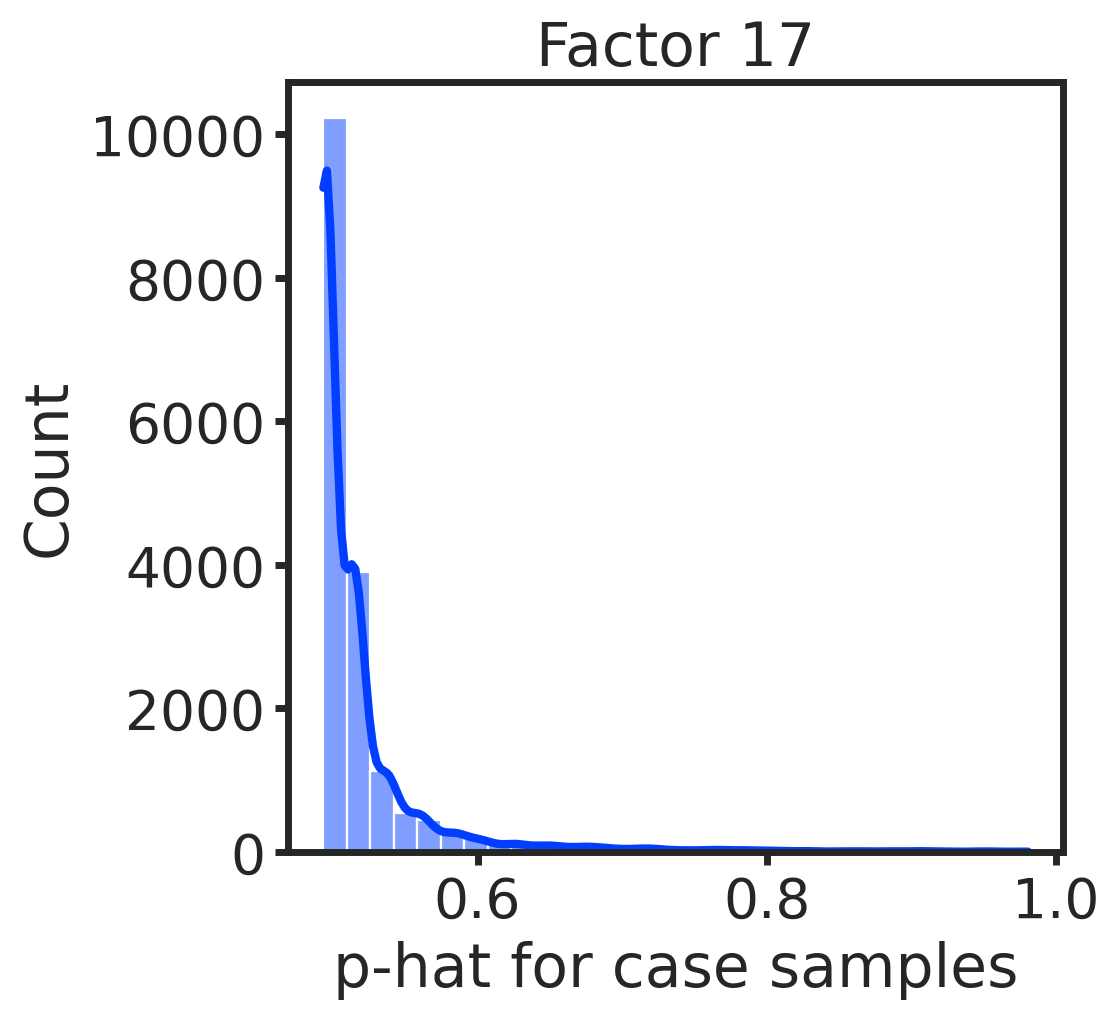

True
Centroids: [0.50811935 0.67301245]
Binarization Threshold: 0.5905659015699064
object
phat_cluster_factor17
case_0       16481
control_0    16030
case_1         894
control_1      421
Name: count, dtype: int64


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000110375', 'ENSMUSG00000100162']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000064115  49.847          11.181  0.000      0.000     Cadm2
1   ENSMUSG00000092341  39.629          35.178  0.000      0.000    Malat1
2   ENSMUSG00000021268  32.527           7.704  0.000      0.000      Meg3
3   ENSMUSG00000061080  30.918           8.066  0.000      0.000     Lsamp
4   ENSMUSG00000033981  30.548           4.257  0.000      0.000     Gria2
5   ENSMUSG00000008658  29.947           7.032  0.000      0.000    Rbfox1
6   ENSMUSG00000061751  29.253           5.164  0.000      0.000     Kalrn
7   ENSMUSG00000028161  28.923           7.851  0.000      0.000    Ppp3ca
8   ENSMUSG00000036438  26.910           4.464  0.000      0.000     Calm2
9   ENSMUSG00000002107  26.710           5.696  0.000      0.000     Celf2
10  ENSMUSG00000055540  26.608           6.973  0.000      0.000     Epha6
11  ENSMUSG00000052727  26.527           3.566  0.000      0.000     Map1b
12  ENSMUSG00000035864  2

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000110375', 'ENSMUSG00000100162']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000064115  49.967          10.979  0.000      0.000     Cadm2
1   ENSMUSG00000092341  42.133          36.611  0.000      0.000    Malat1
2   ENSMUSG00000021268  34.553           8.141  0.000      0.000      Meg3
3   ENSMUSG00000061080  32.368           8.475  0.000      0.000     Lsamp
4   ENSMUSG00000119584  32.069          46.409  0.000      0.000     Rn18s
5   ENSMUSG00000008658  31.293           7.446  0.000      0.000    Rbfox1
6   ENSMUSG00000033981  30.582           4.184  0.000      0.000     Gria2
7   ENSMUSG00000061751  29.792           5.249  0.000      0.000     Kalrn
8   ENSMUSG00000028161  28.175           7.568  0.000      0.000    Ppp3ca
9   ENSMUSG00000052727  27.878           3.778  0.000      0.000     Map1b
10  ENSMUSG00000002107  27.574           5.895  0.000      0.000     Celf2
11  ENSMUSG00000055540  27.340           7.118  0.000      0.000     Epha6
12  ENSMUSG00000020524  2

...

                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000119584  71.723          16.492  0.000      0.000     Rn18s
1   ENSMUSG00000047454  25.146           1.297  0.000      0.000      Gphn
2   ENSMUSG00000022748  24.006           1.393  0.000      0.000     Cmss1
3   ENSMUSG00000035202  20.652           1.045  0.000      0.000     Lars2
4   ENSMUSG00000039145  20.130           0.822  0.000      0.000    Camk1d
5   ENSMUSG00000092341  13.895           2.895  0.000      0.000    Malat1
6   ENSMUSG00000113136  10.099           0.791  0.000      0.000   Gm19951
7   ENSMUSG00000021268   8.482           0.910  0.000      0.000      Meg3
8   ENSMUSG00000007891   7.350           1.743  0.000      0.000      Ctsd
9   ENSMUSG00000028649   6.895           0.764  0.000      0.000     Macf1
10  ENSMUSG00000026131   6.603           0.834  0.000      0.000       Dst
11  ENSMUSG00000061080   6.490           0.894  0.000      0.000     Lsamp
12  ENSMUSG00000052727   

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000119584  72.628          16.744  0.000      0.000     Rn18s
1   ENSMUSG00000047454  26.004           1.357  0.000      0.000      Gphn
2   ENSMUSG00000022748  24.710           1.441  0.000      0.000     Cmss1
3   ENSMUSG00000039145  21.341           0.905  0.000      0.000    Camk1d
4   ENSMUSG00000035202  21.341           1.100  0.000      0.000     Lars2
5   ENSMUSG00000092341  16.713           3.362  0.000      0.000    Malat1
6   ENSMUSG00000021268  10.711           1.101  0.000      0.000      Meg3
7   ENSMUSG00000113136  10.355           0.831  0.000      0.000   Gm19951
8   ENSMUSG00000061080   8.671           1.219  0.000      0.000     Lsamp
9   ENSMUSG00000008658   7.943           1.170  0.000      0.000    Rbfox1
10  ENSMUSG00000052727   7.714           0.557  0.000      0.000     Map1b
11  ENSMUSG00000028649   7.502           0.853  0.000      0.000     Macf1
12  ENSMUSG00000007891   

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']
/tmp/ipykernel_1414540/1374827707.py:349: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparisons, y=sig_de_counts, palette="viridis")


-----------------------------------
Control1 vs Control0
                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000064115  34.864          10.021  0.000      0.000     Cadm2
1   ENSMUSG00000092341  26.282          17.333  0.000      0.000    Malat1
2   ENSMUSG00000028161  23.970          10.141  0.000      0.000    Ppp3ca
3   ENSMUSG00000036438  21.480           6.264  0.000      0.000     Calm2
4   ENSMUSG00000021268  20.545           5.637  0.000      0.000      Meg3
5   ENSMUSG00000028785  20.381           6.419  0.000      0.000      Hpca
6   ENSMUSG00000033981  20.340           4.265  0.000      0.000     Gria2
7   ENSMUSG00000008658  20.330           4.870  0.000      0.000    Rbfox1
8   ENSMUSG00000061080  19.742           5.972  0.000      0.000     Lsamp
9   ENSMUSG00000056486  19.295           3.675  0.000      0.000      Chn1
10  ENSMUSG00000026576  18.771           3.806  0.000      0.000    Atp1b1
11  ENSMUSG00000026833  18.329           4.

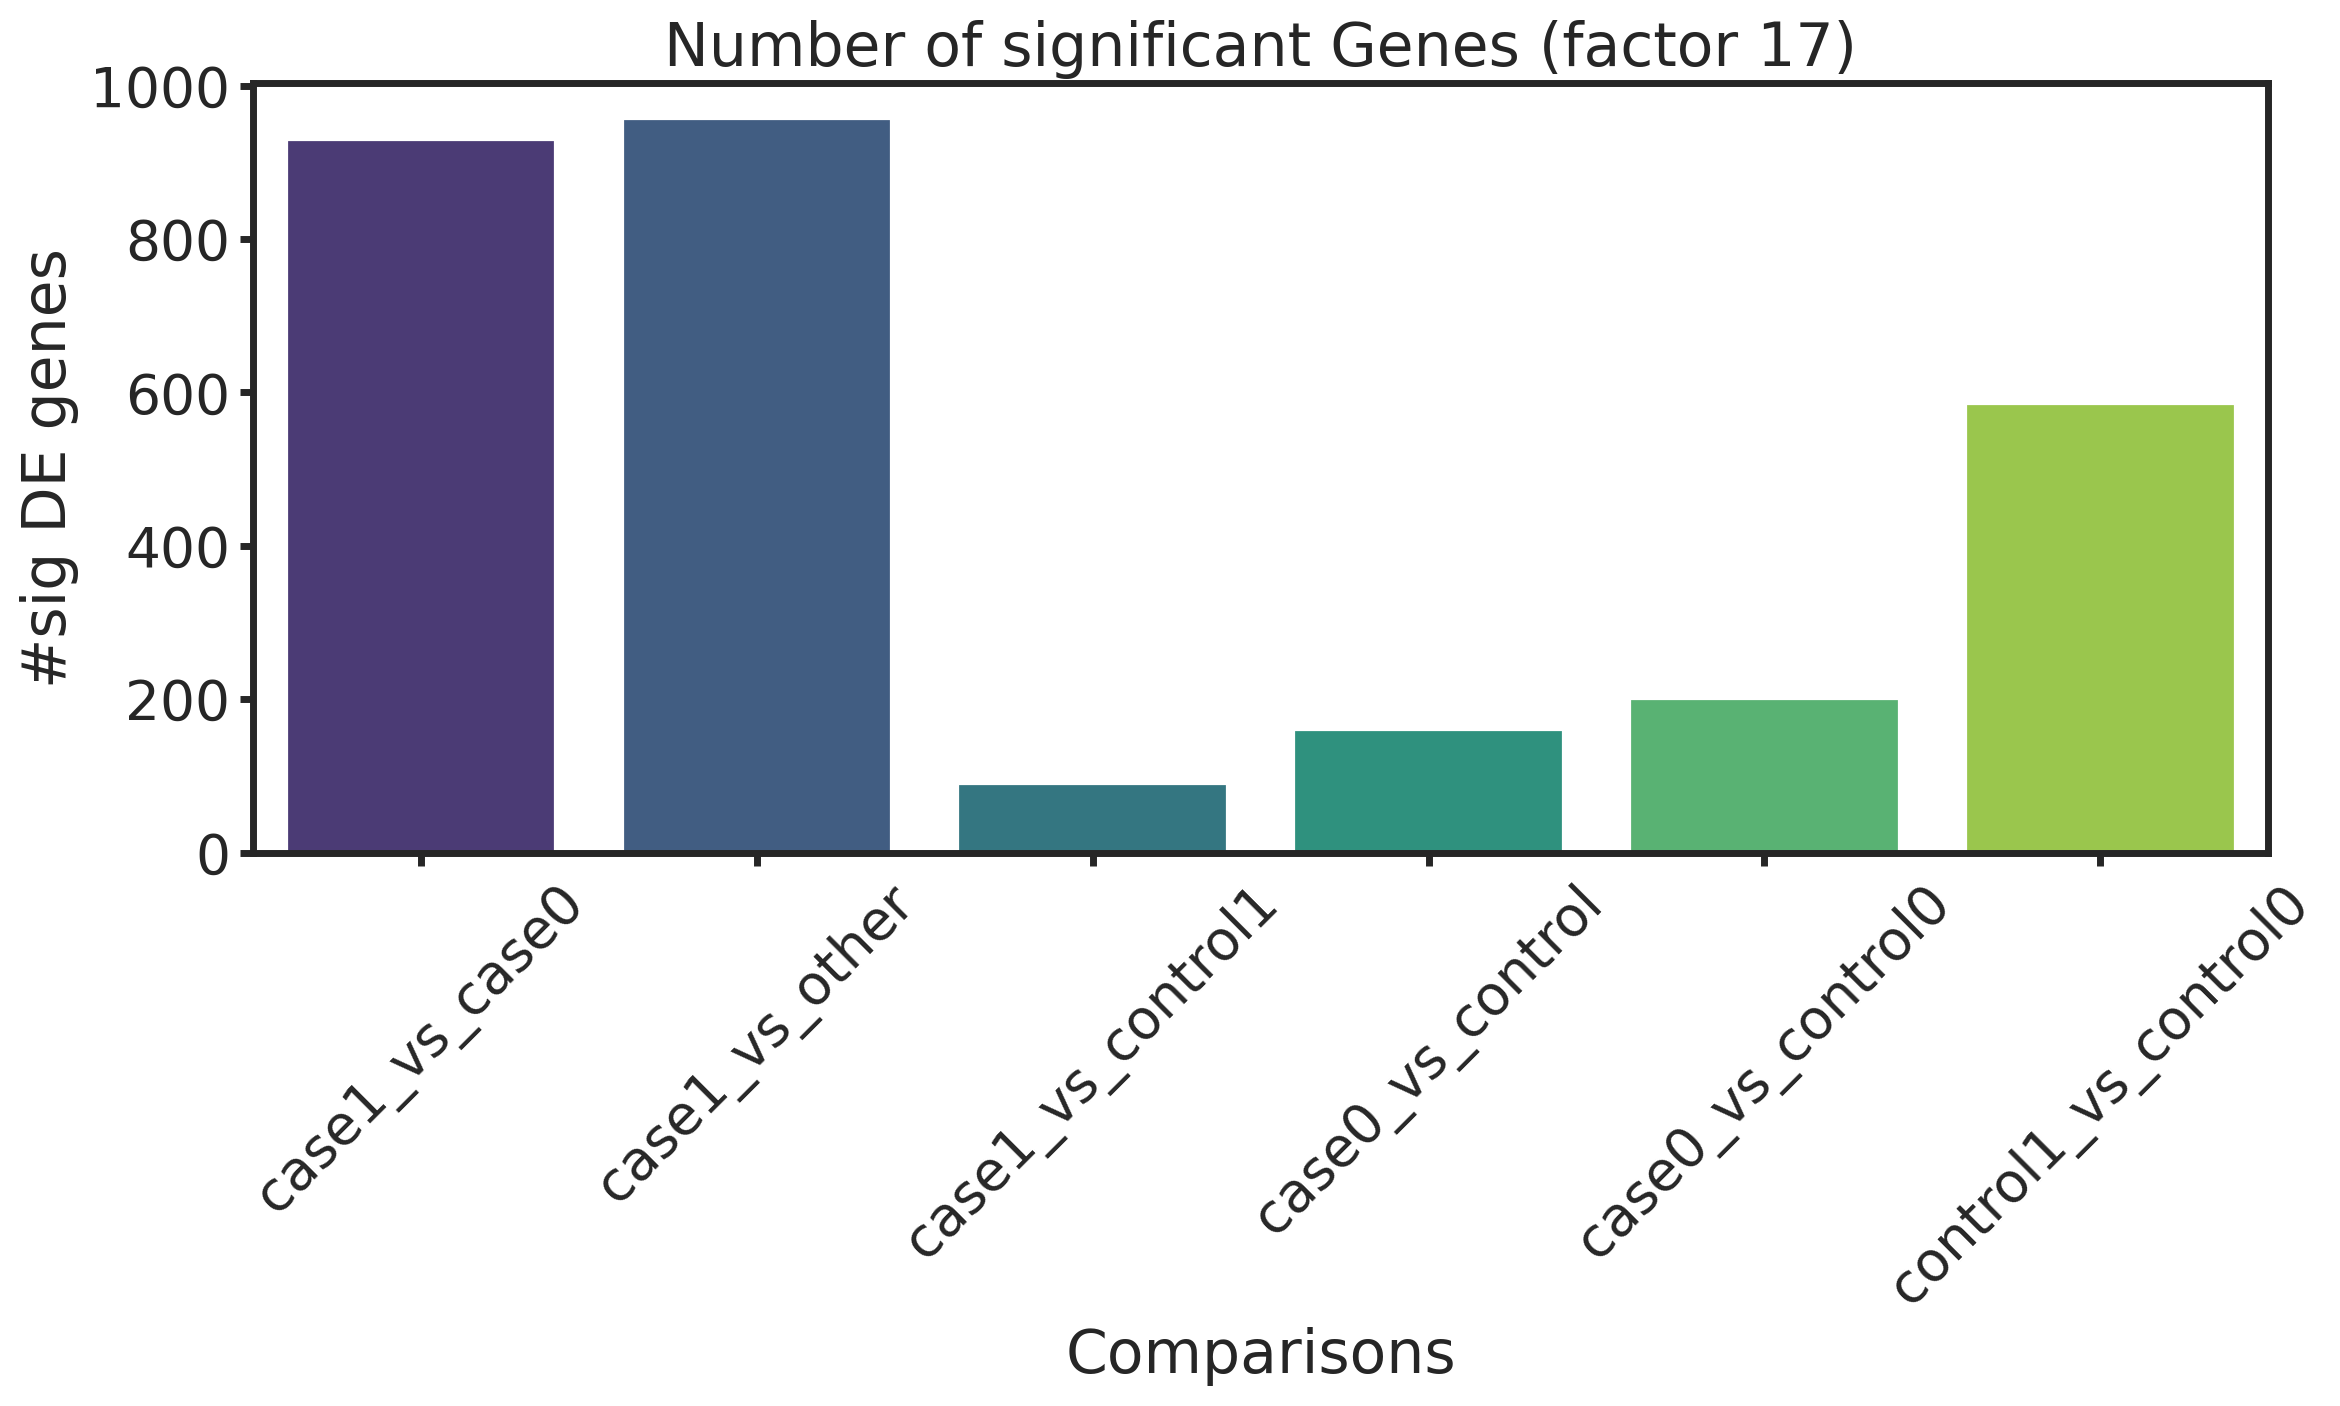

Factor 29


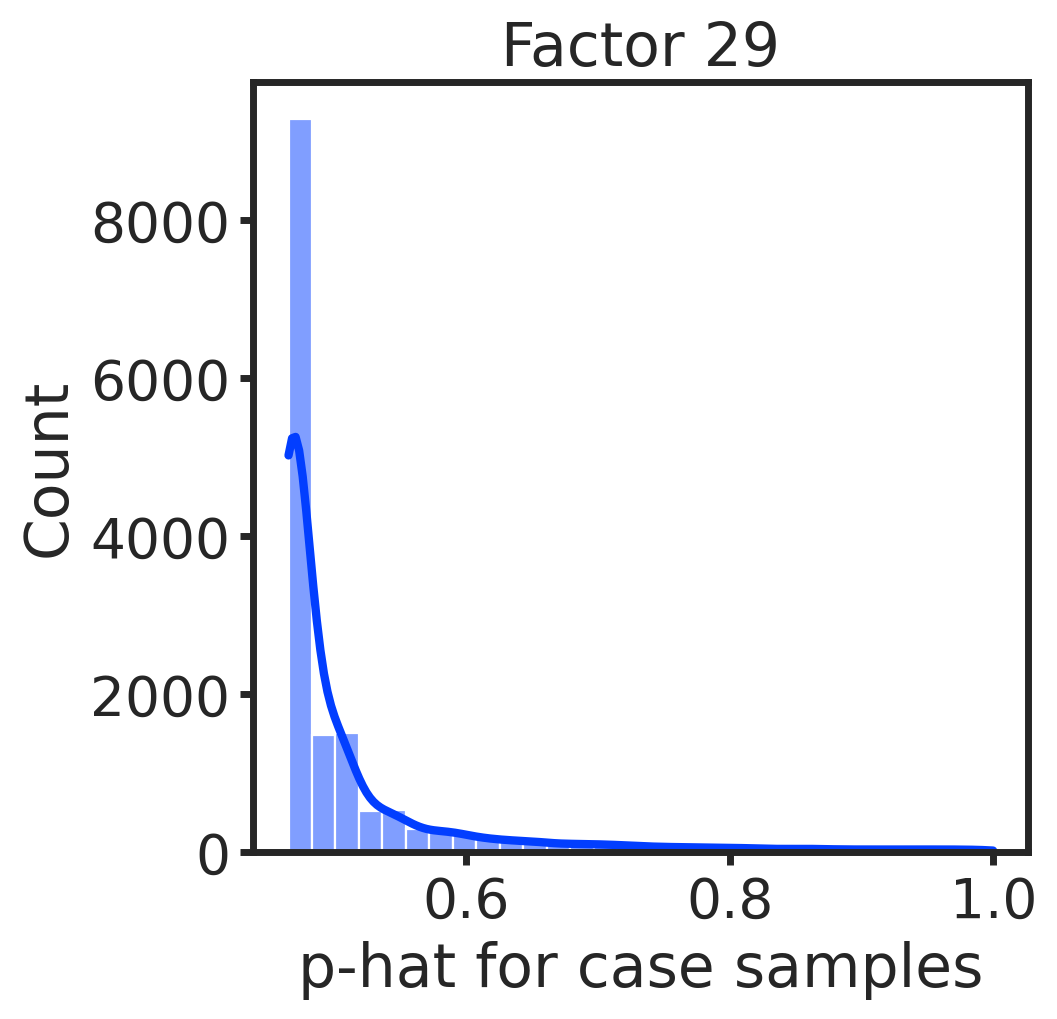

True
Centroids: [0.74678275 0.48723646]
Binarization Threshold: 0.6170096035380108
object
phat_cluster_factor29
control_0    15062
case_0       14173
case_1        1329
control_1      486
Name: count, dtype: int64


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000110375', 'ENSMUSG00000100162']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000052572  55.690          10.861  0.000      0.000      Dlg2
1   ENSMUSG00000092341  48.393          34.299  0.000      0.000    Malat1
2   ENSMUSG00000021268  38.780           7.761  0.000      0.000      Meg3
3   ENSMUSG00000033981  31.876           3.704  0.000      0.000     Gria2
4   ENSMUSG00000060924  31.288           6.330  0.000      0.000     Csmd1
5   ENSMUSG00000028161  31.190           6.137  0.000      0.000    Ppp3ca
6   ENSMUSG00000008658  31.144           6.076  0.000      0.000    Rbfox1
7   ENSMUSG00000002107  30.214           5.527  0.000      0.000     Celf2
8   ENSMUSG00000064115  29.609           4.655  0.000      0.000     Cadm2
9   ENSMUSG00000003279  29.339           4.206  0.000      0.000    Dlgap1
10  ENSMUSG00000061080  29.151           6.140  0.000      0.000     Lsamp
11  ENSMUSG00000061751  28.958           4.379  0.000      0.000     Kalrn
12  ENSMUSG00000044349  2

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000110375', 'ENSMUSG00000100162']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000052572  56.355          10.631  0.000      0.000      Dlg2
1   ENSMUSG00000092341  51.960          35.703  0.000      0.000    Malat1
2   ENSMUSG00000021268  41.805           8.223  0.000      0.000      Meg3
3   ENSMUSG00000119584  39.496          41.363  0.000      0.000     Rn18s
4   ENSMUSG00000008658  32.974           6.454  0.000      0.000    Rbfox1
5   ENSMUSG00000060924  32.910           6.531  0.000      0.000     Csmd1
6   ENSMUSG00000033981  32.107           3.620  0.000      0.000     Gria2
7   ENSMUSG00000002107  31.663           5.716  0.000      0.000     Celf2
8   ENSMUSG00000061080  31.210           6.559  0.000      0.000     Lsamp
9   ENSMUSG00000064115  31.040           4.858  0.000      0.000     Cadm2
10  ENSMUSG00000044349  30.699           3.779  0.000      0.000    Snhg11
11  ENSMUSG00000003279  30.579           4.397  0.000      0.000    Dlgap1
12  ENSMUSG00000028161  3

...

                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000119584  67.895          15.083  0.000      0.000     Rn18s
1   ENSMUSG00000022748  21.482           1.325  0.000      0.000     Cmss1
2   ENSMUSG00000047454  20.376           1.177  0.000      0.000      Gphn
3   ENSMUSG00000039145  18.292           0.830  0.000      0.000    Camk1d
4   ENSMUSG00000035202  17.525           1.009  0.000      0.000     Lars2
5   ENSMUSG00000092341  16.048           2.713  0.000      0.000    Malat1
6   ENSMUSG00000021268  10.428           0.916  0.000      0.000      Meg3
7   ENSMUSG00000113136   8.649           0.750  0.000      0.000   Gm19951
8   ENSMUSG00000052727   6.568           0.488  0.000      0.000     Map1b
9   ENSMUSG00000061080   6.379           0.874  0.000      0.000     Lsamp
10  ENSMUSG00000007891   6.378           1.701  0.000      0.000      Ctsd
11  ENSMUSG00000028649   6.127           0.749  0.000      0.000     Macf1
12  ENSMUSG00000060882   

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000119584  68.780          15.343  0.000      0.000     Rn18s
1   ENSMUSG00000022748  22.103           1.375  0.000      0.000     Cmss1
2   ENSMUSG00000047454  21.313           1.242  0.000      0.000      Gphn
3   ENSMUSG00000039145  19.507           0.906  0.000      0.000    Camk1d
4   ENSMUSG00000092341  19.460           3.277  0.000      0.000    Malat1
5   ENSMUSG00000035202  18.202           1.051  0.000      0.000     Lars2
6   ENSMUSG00000021268  13.432           1.194  0.000      0.000      Meg3
7   ENSMUSG00000113136   8.898           0.793  0.000      0.000   Gm19951
8   ENSMUSG00000052727   8.180           0.584  0.000      0.000     Map1b
9   ENSMUSG00000061080   8.139           1.148  0.000      0.000     Lsamp
10  ENSMUSG00000060924   7.411           0.777  0.000      0.000     Csmd1
11  ENSMUSG00000041014   7.284           1.140  0.000      0.000      Nrg3
12  ENSMUSG00000044349   

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000110375', 'ENSMUSG00000100162']
/tmp/ipykernel_1414540/1374827707.py:349: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparisons, y=sig_de_counts, palette="viridis")


-----------------------------------
Control1 vs Control0
                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000052572  35.992           9.939  0.000      0.000      Dlg2
1   ENSMUSG00000092341  29.035          17.000  0.000      0.000    Malat1
2   ENSMUSG00000021268  25.207           6.676  0.000      0.000      Meg3
3   ENSMUSG00000028161  21.313           7.259  0.000      0.000    Ppp3ca
4   ENSMUSG00000036438  20.694           4.929  0.000      0.000     Calm2
5   ENSMUSG00000033981  19.467           3.698  0.000      0.000     Gria2
6   ENSMUSG00000002107  18.768           4.513  0.000      0.000     Celf2
7   ENSMUSG00000026833  17.769           3.715  0.000      0.000     Olfm1
8   ENSMUSG00000056486  17.693           3.017  0.000      0.000      Chn1
9   ENSMUSG00000008658  17.631           4.764  0.000      0.000    Rbfox1
10  ENSMUSG00000044349  17.616           3.546  0.000      0.000    Snhg11
11  ENSMUSG00000053310  17.172           2.

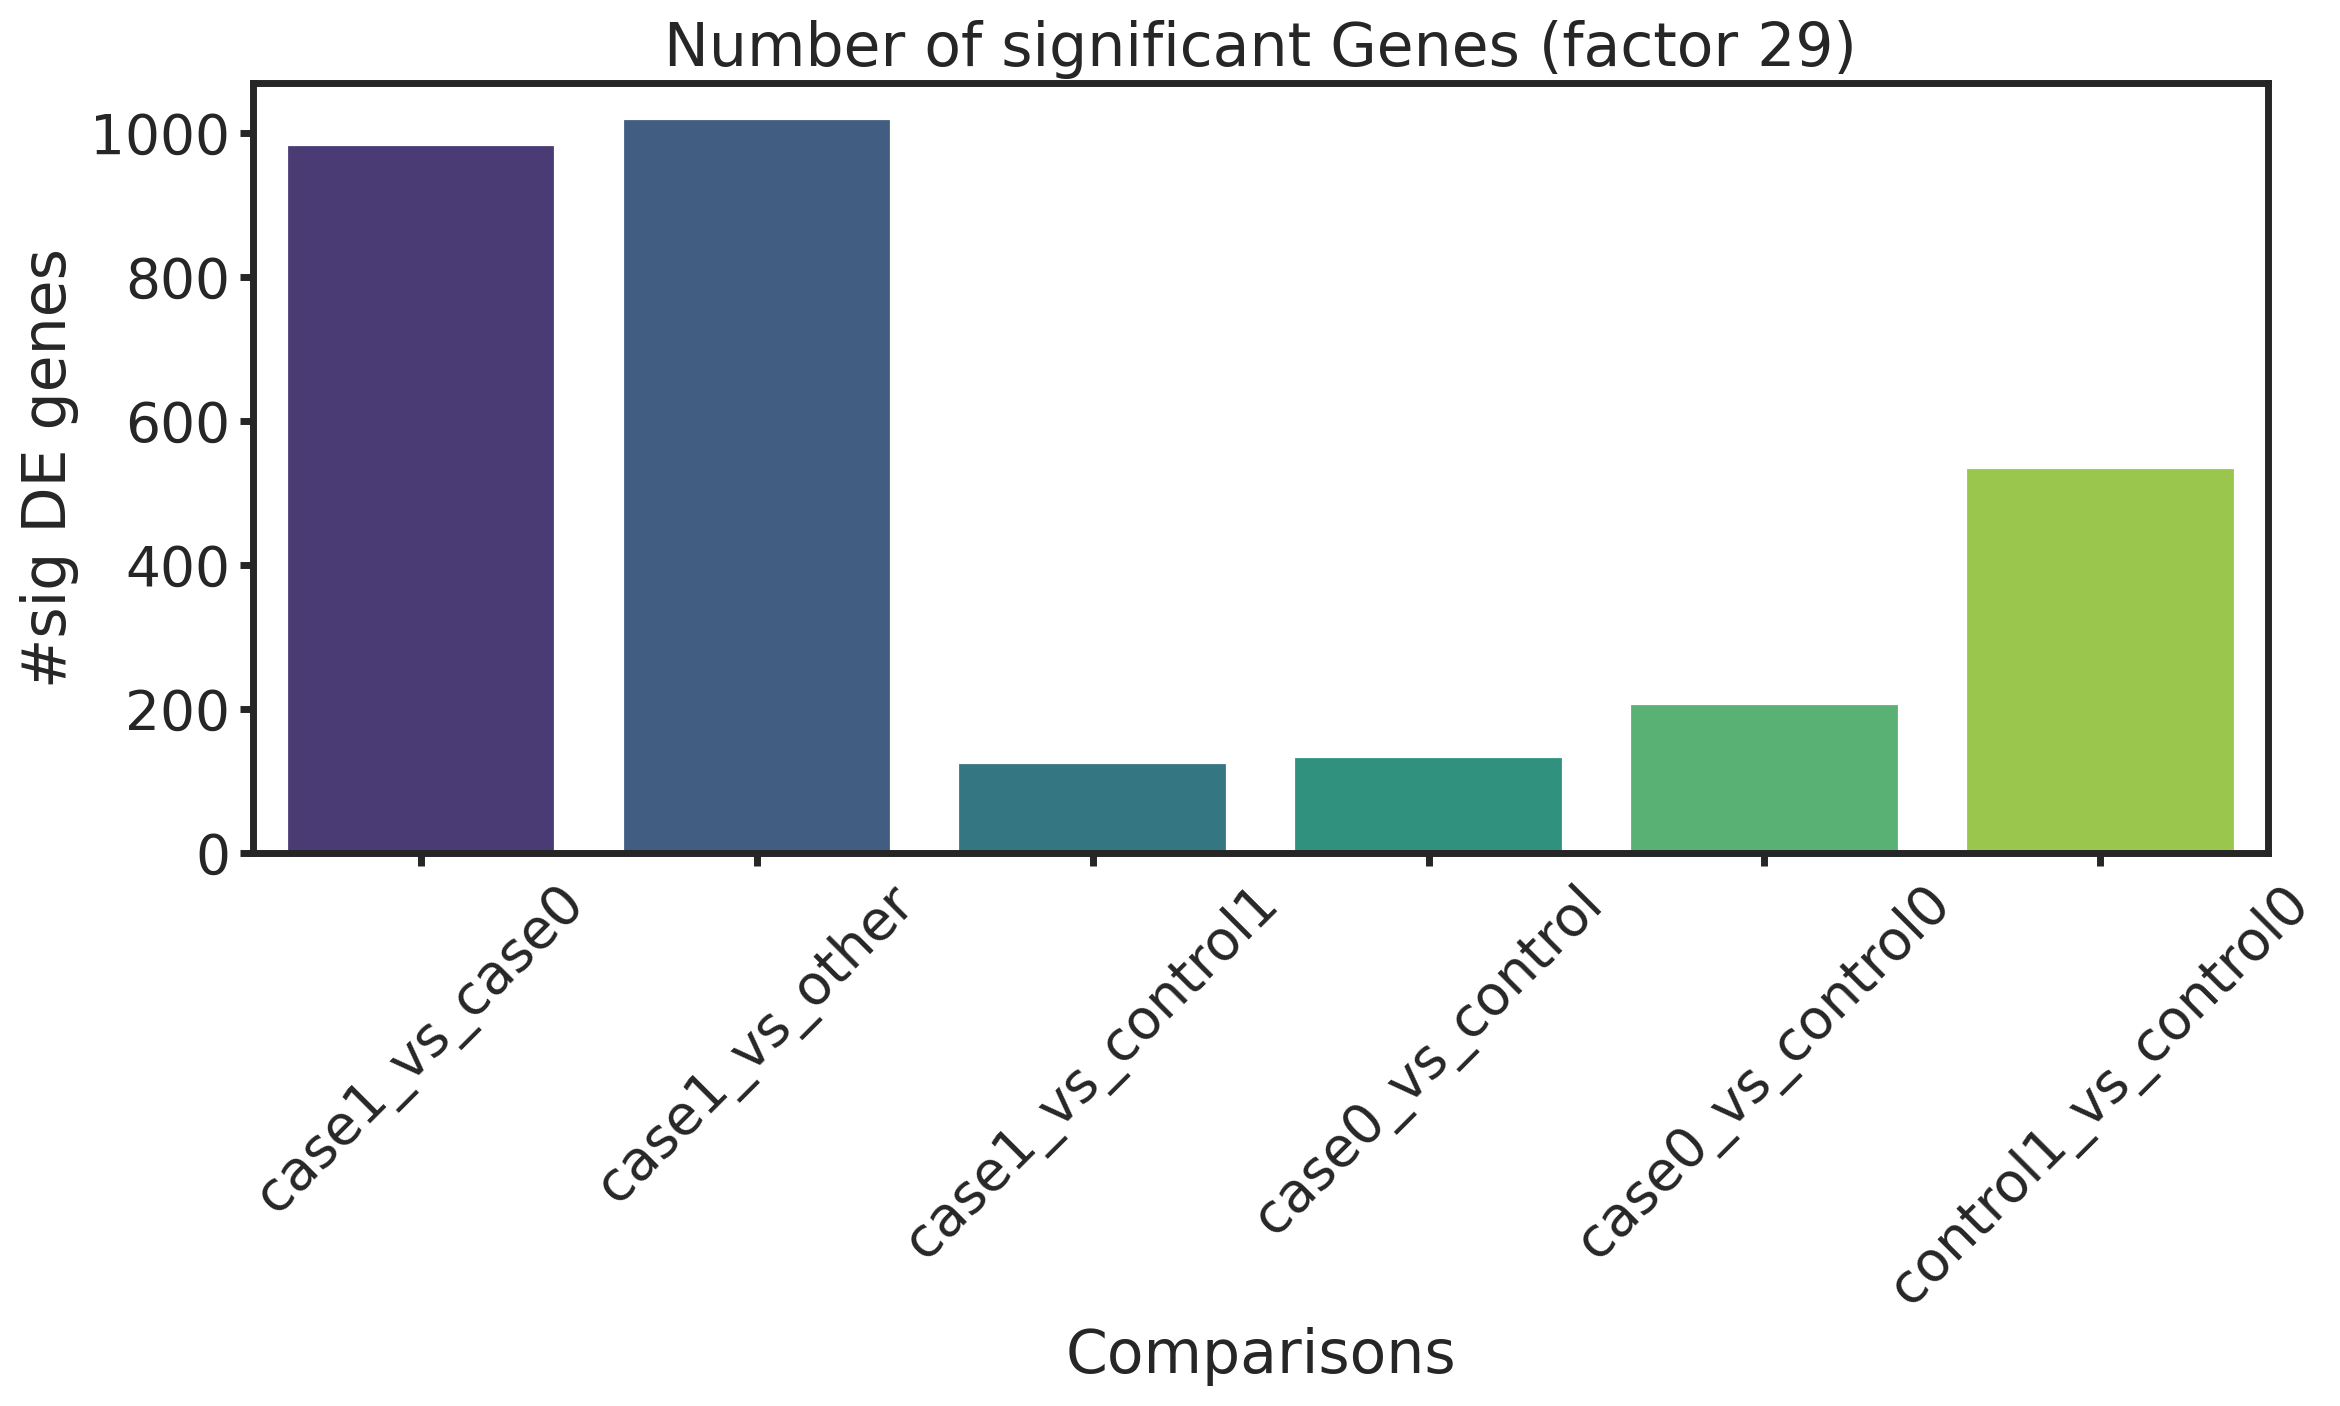

Factor 1


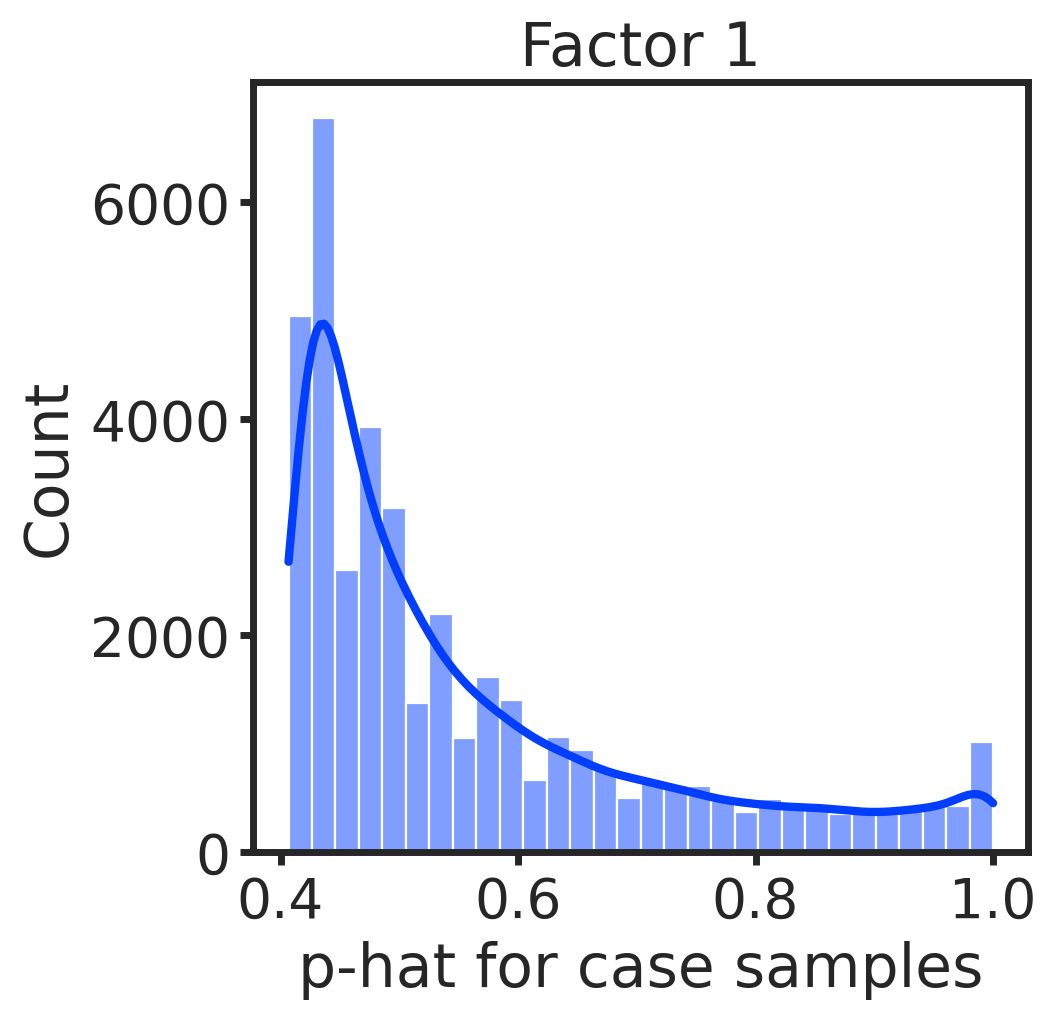

True
Centroids: [0.81106895 0.48608626]
Binarization Threshold: 0.6485776031481427
object
phat_cluster_factor1
control_0    35084
case_0       30881
case_1        9453
control_1     2191
Name: count, dtype: int64


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000119584 147.330          60.689  0.000      0.000     Rn18s
1   ENSMUSG00000047454  79.905           3.914  0.000      0.000      Gphn
2   ENSMUSG00000039145  79.522           4.303  0.000      0.000    Camk1d
3   ENSMUSG00000035202  78.840           3.928  0.000      0.000     Lars2
4   ENSMUSG00000022748  76.724           3.883  0.000      0.000     Cmss1
5   ENSMUSG00000113136  39.484           2.600  0.000      0.000   Gm19951
6   ENSMUSG00000092341  38.603           8.307  0.000      0.000    Malat1
7   ENSMUSG00000052727  28.063           1.895  0.000      0.000     Map1b
8   ENSMUSG00000035864  21.132           1.634  0.000      0.000      Syt1
9   ENSMUSG00000036438  20.673           1.217  0.000      0.000     Calm2
10  ENSMUSG00000026576  20.466           1.239  0.000      0.000    Atp1b1
11  ENSMUSG00000064115  19.514           2.016  0.000      0.000     Cadm2
12  ENSMUSG00000096054  1

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000119584 153.289          60.984  0.000      0.000     Rn18s
1   ENSMUSG00000047454  84.541           3.802  0.000      0.000      Gphn
2   ENSMUSG00000039145  81.918           3.921  0.000      0.000    Camk1d
3   ENSMUSG00000035202  81.764           3.654  0.000      0.000     Lars2
4   ENSMUSG00000022748  81.641           3.803  0.000      0.000     Cmss1
5   ENSMUSG00000092341  42.397           8.700  0.000      0.000    Malat1
6   ENSMUSG00000113136  41.153           2.406  0.000      0.000   Gm19951
7   ENSMUSG00000052727  28.905           1.824  0.000      0.000     Map1b
8   ENSMUSG00000096054  21.124           2.026  0.000      0.000     Syne1
9   ENSMUSG00000021268  20.300           2.232  0.000      0.000      Meg3
10  ENSMUSG00000064115  20.210           1.994  0.000      0.000     Cadm2
11  ENSMUSG00000055421  19.459           1.872  0.000      0.000     Pcdh9
12  ENSMUSG00000032826  1

...

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000119584  73.351           3.861  0.000      0.000     Rn18s
1   ENSMUSG00000007891   8.913           1.704  0.000      0.000      Ctsd
2   ENSMUSG00000026728   6.802           2.037  0.000      0.000       Vim
3   ENSMUSG00000022748   5.613           0.172  0.000      0.000     Cmss1
4   ENSMUSG00000047454   5.525           0.125  0.000      0.000      Gphn
5   ENSMUSG00000021268   5.463           0.539  0.000      0.000      Meg3
6   ENSMUSG00000050708   5.281           1.327  0.000      0.000      Ftl1
7   ENSMUSG00000019874   4.897           0.835  0.000      0.000     Fabp7
8   ENSMUSG00000061080   4.615           0.636  0.000      0.000     Lsamp
9   ENSMUSG00000092341   4.595           1.026  0.000      0.000    Malat1
10  ENSMUSG00000068220   4.519           1.418  0.000      0.000    Lgals1
11  ENSMUSG00000029304   4.512           4.402  0.000      0.000      Spp1
12  ENSMUSG00000029088   

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


-----------------------------------
Control1 vs Control0
                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000119584  78.648          56.073  0.000      0.000     Rn18s
1   ENSMUSG00000039145  47.910           5.968  0.000      0.000    Camk1d
2   ENSMUSG00000035202  40.917           4.187  0.000      0.000     Lars2
3   ENSMUSG00000047454  40.003           3.515  0.000      0.000      Gphn
4   ENSMUSG00000022748  35.327           3.184  0.000      0.000     Cmss1
5   ENSMUSG00000092341  21.116           4.759  0.000      0.000    Malat1
6   ENSMUSG00000113136  20.921           2.713  0.000      0.000   Gm19951
7   ENSMUSG00000036438  17.001           1.898  0.000      0.000     Calm2
8   ENSMUSG00000027273  15.259           1.842  0.000      0.000    Snap25
9   ENSMUSG00000002985  14.960           1.243  0.000      0.000      Apoe
10  ENSMUSG00000026576  14.328           1.741  0.000      0.000    Atp1b1
11  ENSMUSG00000052727  13.730           1.

/tmp/ipykernel_1414540/1374827707.py:349: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparisons, y=sig_de_counts, palette="viridis")


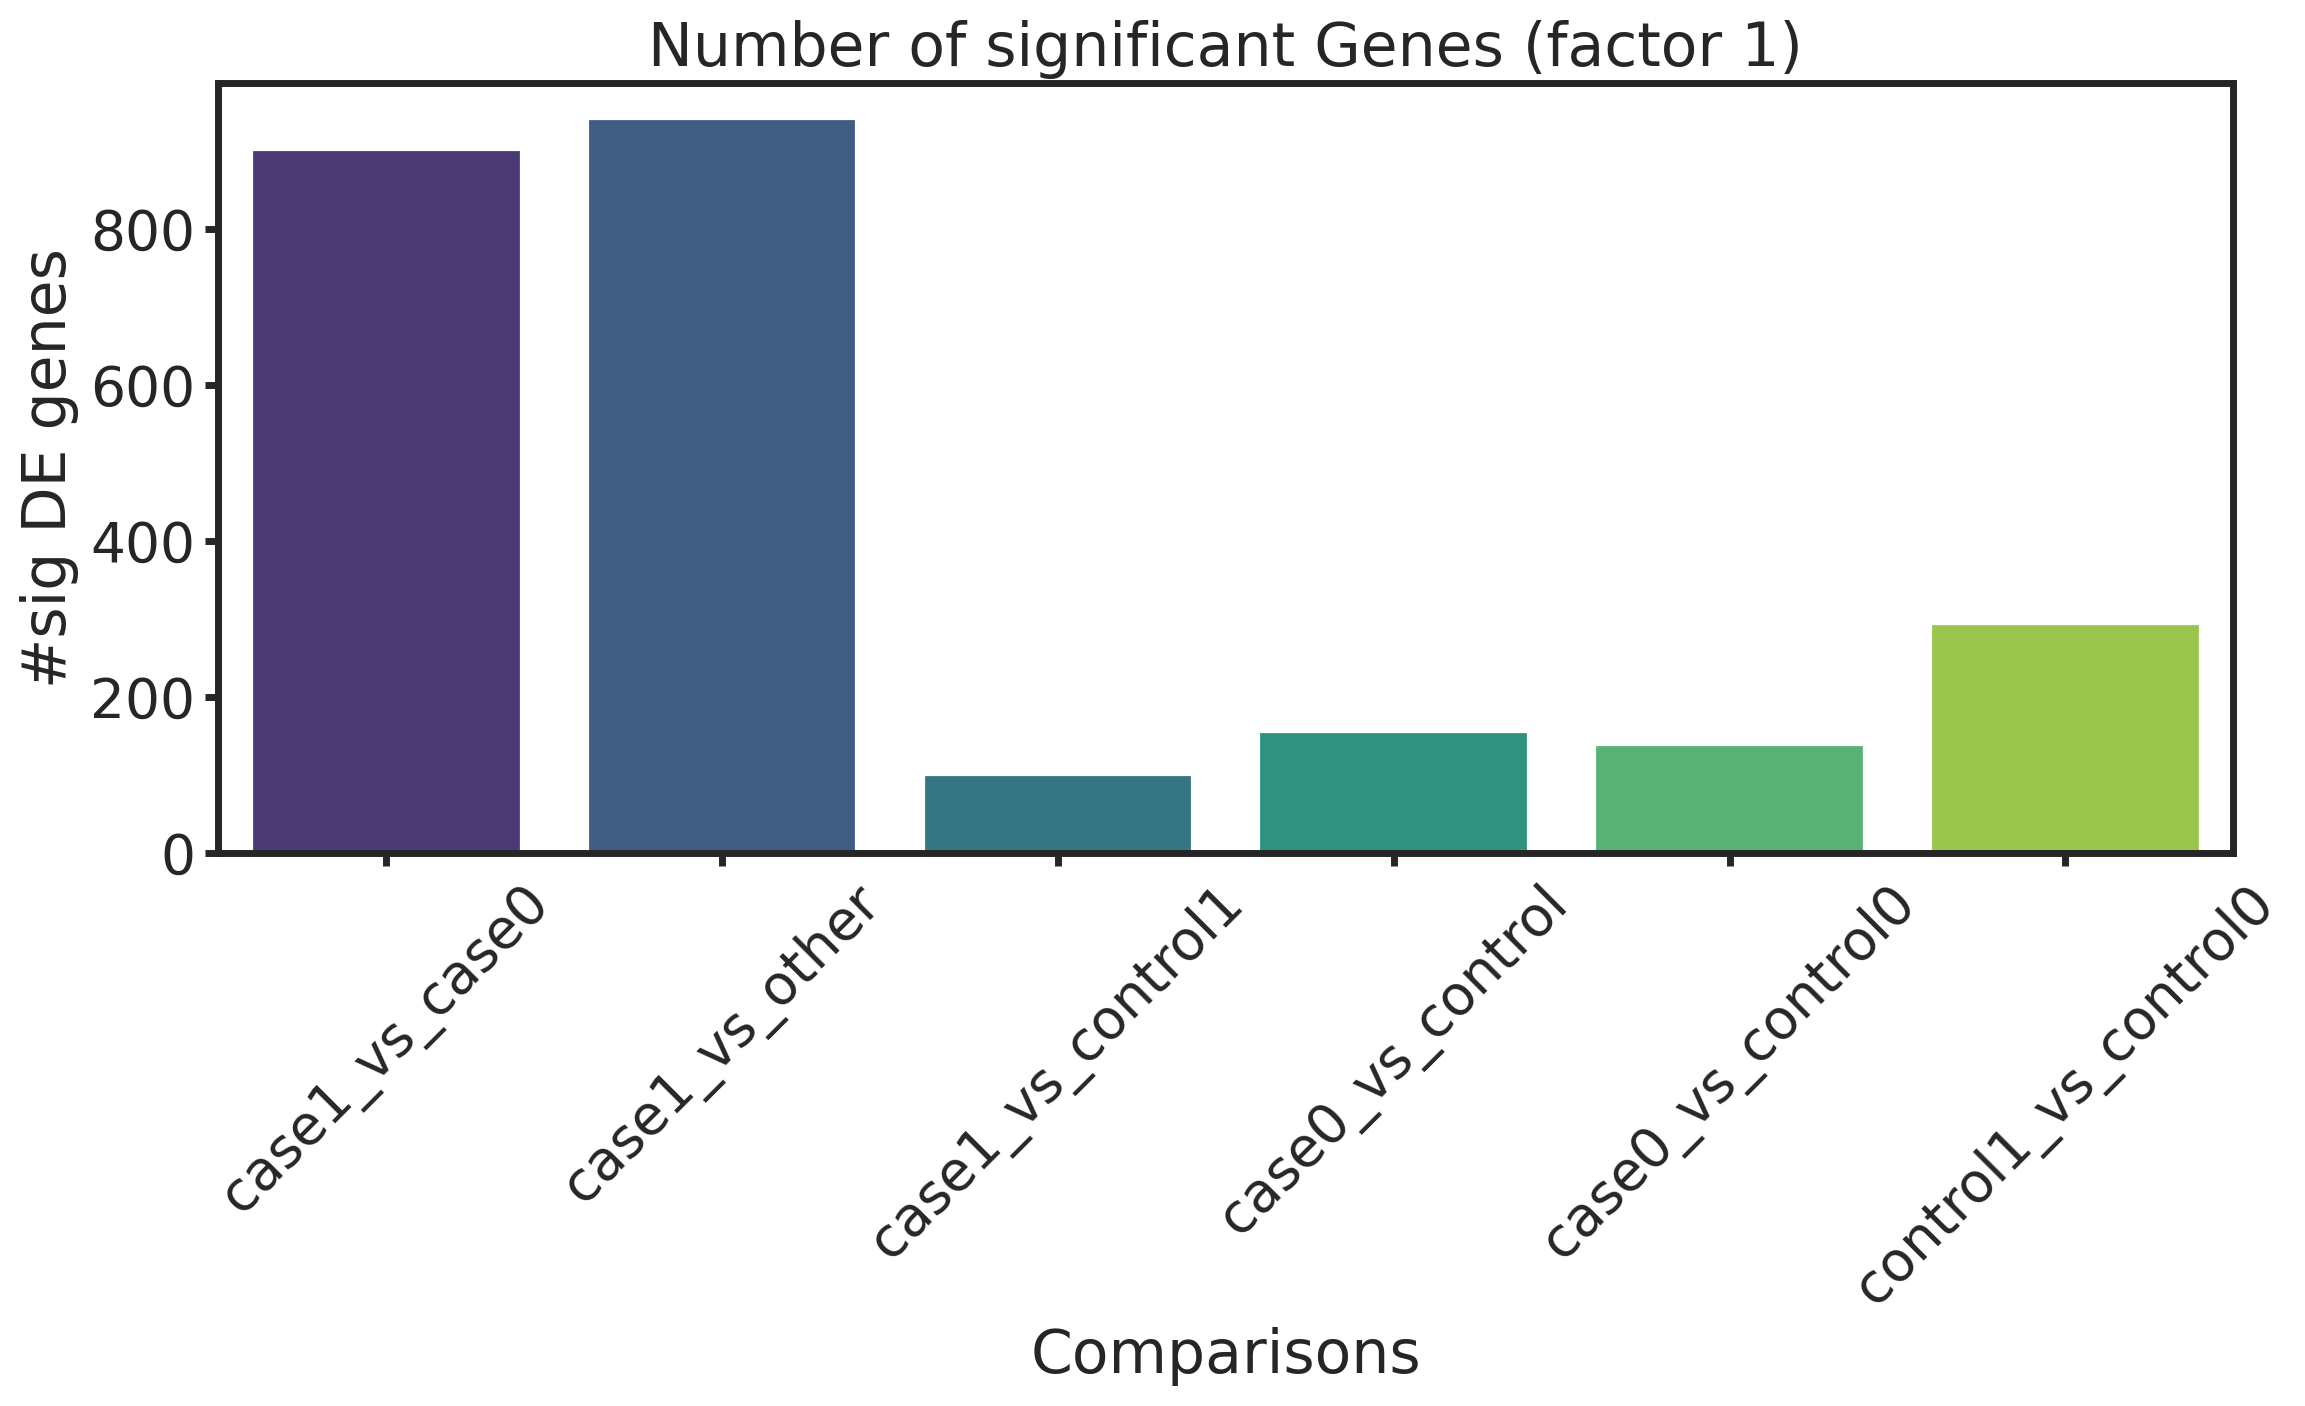

Factor 5


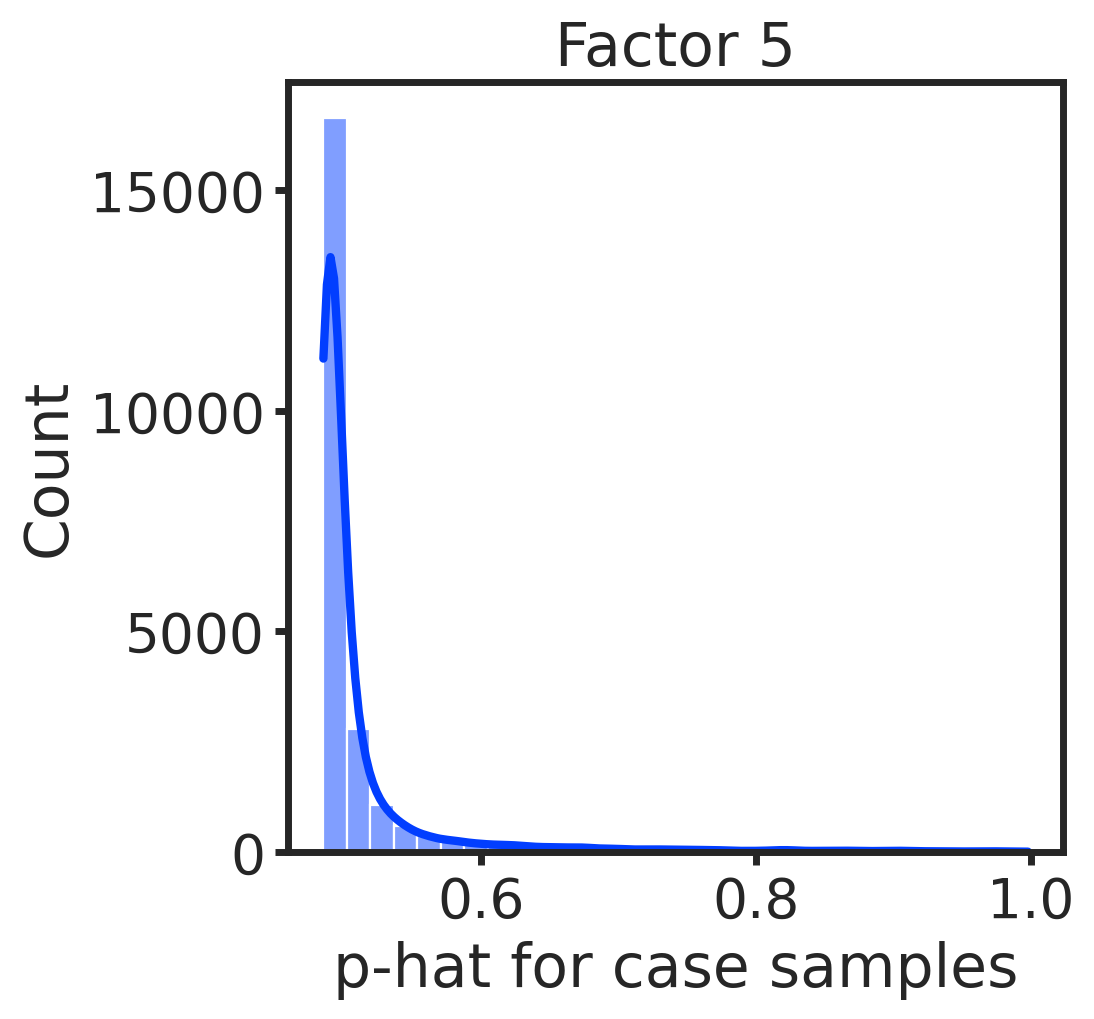

True
Centroids: [0.49984515 0.719527  ]
Binarization Threshold: 0.6096860725101683
object
phat_cluster_factor5
control_0    21945
case_0       21919
case_1        1050
control_1      505
Name: count, dtype: int64


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000110375', 'ENSMUSG00000100162']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000092341  47.967          37.453  0.000      0.000    Malat1
1   ENSMUSG00000028161  46.823          11.300  0.000      0.000    Ppp3ca
2   ENSMUSG00000033981  41.565           5.356  0.000      0.000     Gria2
3   ENSMUSG00000052581  39.693           9.638  0.000      0.000    Lrrtm4
4   ENSMUSG00000057897  39.255           4.990  0.000      0.000    Camk2b
5   ENSMUSG00000061751  39.205           6.150  0.000      0.000     Kalrn
6   ENSMUSG00000020524  39.132           5.849  0.000      0.000     Gria1
7   ENSMUSG00000022708  38.533           6.271  0.000      0.000    Zbtb20
8   ENSMUSG00000026833  38.236           5.247  0.000      0.000     Olfm1
9   ENSMUSG00000028785  37.935           5.294  0.000      0.000      Hpca
10  ENSMUSG00000003279  37.902           6.572  0.000      0.000    Dlgap1
11  ENSMUSG00000002107  37.328           6.656  0.000      0.000     Celf2
12  ENSMUSG00000056486  3

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000110375', 'ENSMUSG00000100162']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000092341  49.947          38.503  0.000      0.000    Malat1
1   ENSMUSG00000028161  46.487          10.966  0.000      0.000    Ppp3ca
2   ENSMUSG00000033981  41.688           5.258  0.000      0.000     Gria2
3   ENSMUSG00000020524  39.983           5.989  0.000      0.000     Gria1
4   ENSMUSG00000052581  39.967           9.411  0.000      0.000    Lrrtm4
5   ENSMUSG00000061751  39.710           6.192  0.000      0.000     Kalrn
6   ENSMUSG00000057897  39.585           4.946  0.000      0.000    Camk2b
7   ENSMUSG00000022708  39.166           6.323  0.000      0.000    Zbtb20
8   ENSMUSG00000028785  38.595           5.429  0.000      0.000      Hpca
9   ENSMUSG00000003279  38.315           6.582  0.000      0.000    Dlgap1
10  ENSMUSG00000002107  38.142           6.811  0.000      0.000     Celf2
11  ENSMUSG00000056486  36.515           4.323  0.000      0.000      Chn1
12  ENSMUSG00000026833  3

...

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000119584  79.201          13.964  0.000      0.000     Rn18s
1   ENSMUSG00000047454  24.376           1.175  0.000      0.000      Gphn
2   ENSMUSG00000022748  23.482           1.266  0.000      0.000     Cmss1
3   ENSMUSG00000039145  23.023           0.855  0.000      0.000    Camk1d
4   ENSMUSG00000035202  21.851           1.009  0.000      0.000     Lars2
5   ENSMUSG00000092341  18.578           2.674  0.000      0.000    Malat1
6   ENSMUSG00000021268  13.072           1.248  0.000      0.000      Meg3
7   ENSMUSG00000052727  11.455           0.562  0.000      0.000     Map1b
8   ENSMUSG00000113136  10.289           0.859  0.000      0.000   Gm19951
9   ENSMUSG00000061080   9.199           1.194  0.000      0.000     Lsamp
10  ENSMUSG00000028649   8.007           0.982  0.000      0.000     Macf1
11  ENSMUSG00000044349   7.933           0.751  0.000      0.000    Snhg11
12  ENSMUSG00000055421   

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000110375', 'ENSMUSG00000100162']


-----------------------------------
Control1 vs Control0
                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000028161  35.732          14.829  0.000      0.000    Ppp3ca
1   ENSMUSG00000092341  35.026          22.378  0.000      0.000    Malat1
2   ENSMUSG00000026833  32.098           7.111  0.000      0.000     Olfm1
3   ENSMUSG00000033981  30.278           5.480  0.000      0.000     Gria2
4   ENSMUSG00000028833  29.829           5.566  0.000      0.000      Ncdn
5   ENSMUSG00000052581  29.688           8.351  0.000      0.000    Lrrtm4
6   ENSMUSG00000056486  29.047           4.749  0.000      0.000      Chn1
7   ENSMUSG00000036438  28.818           5.991  0.000      0.000     Calm2
8   ENSMUSG00000057897  28.547           5.126  0.000      0.000    Camk2b
9   ENSMUSG00000053310  28.077           4.812  0.000      0.000      Nrgn
10  ENSMUSG00000022708  27.679           5.601  0.000      0.000    Zbtb20
11  ENSMUSG00000002107  27.468           6.

/tmp/ipykernel_1414540/1374827707.py:349: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparisons, y=sig_de_counts, palette="viridis")


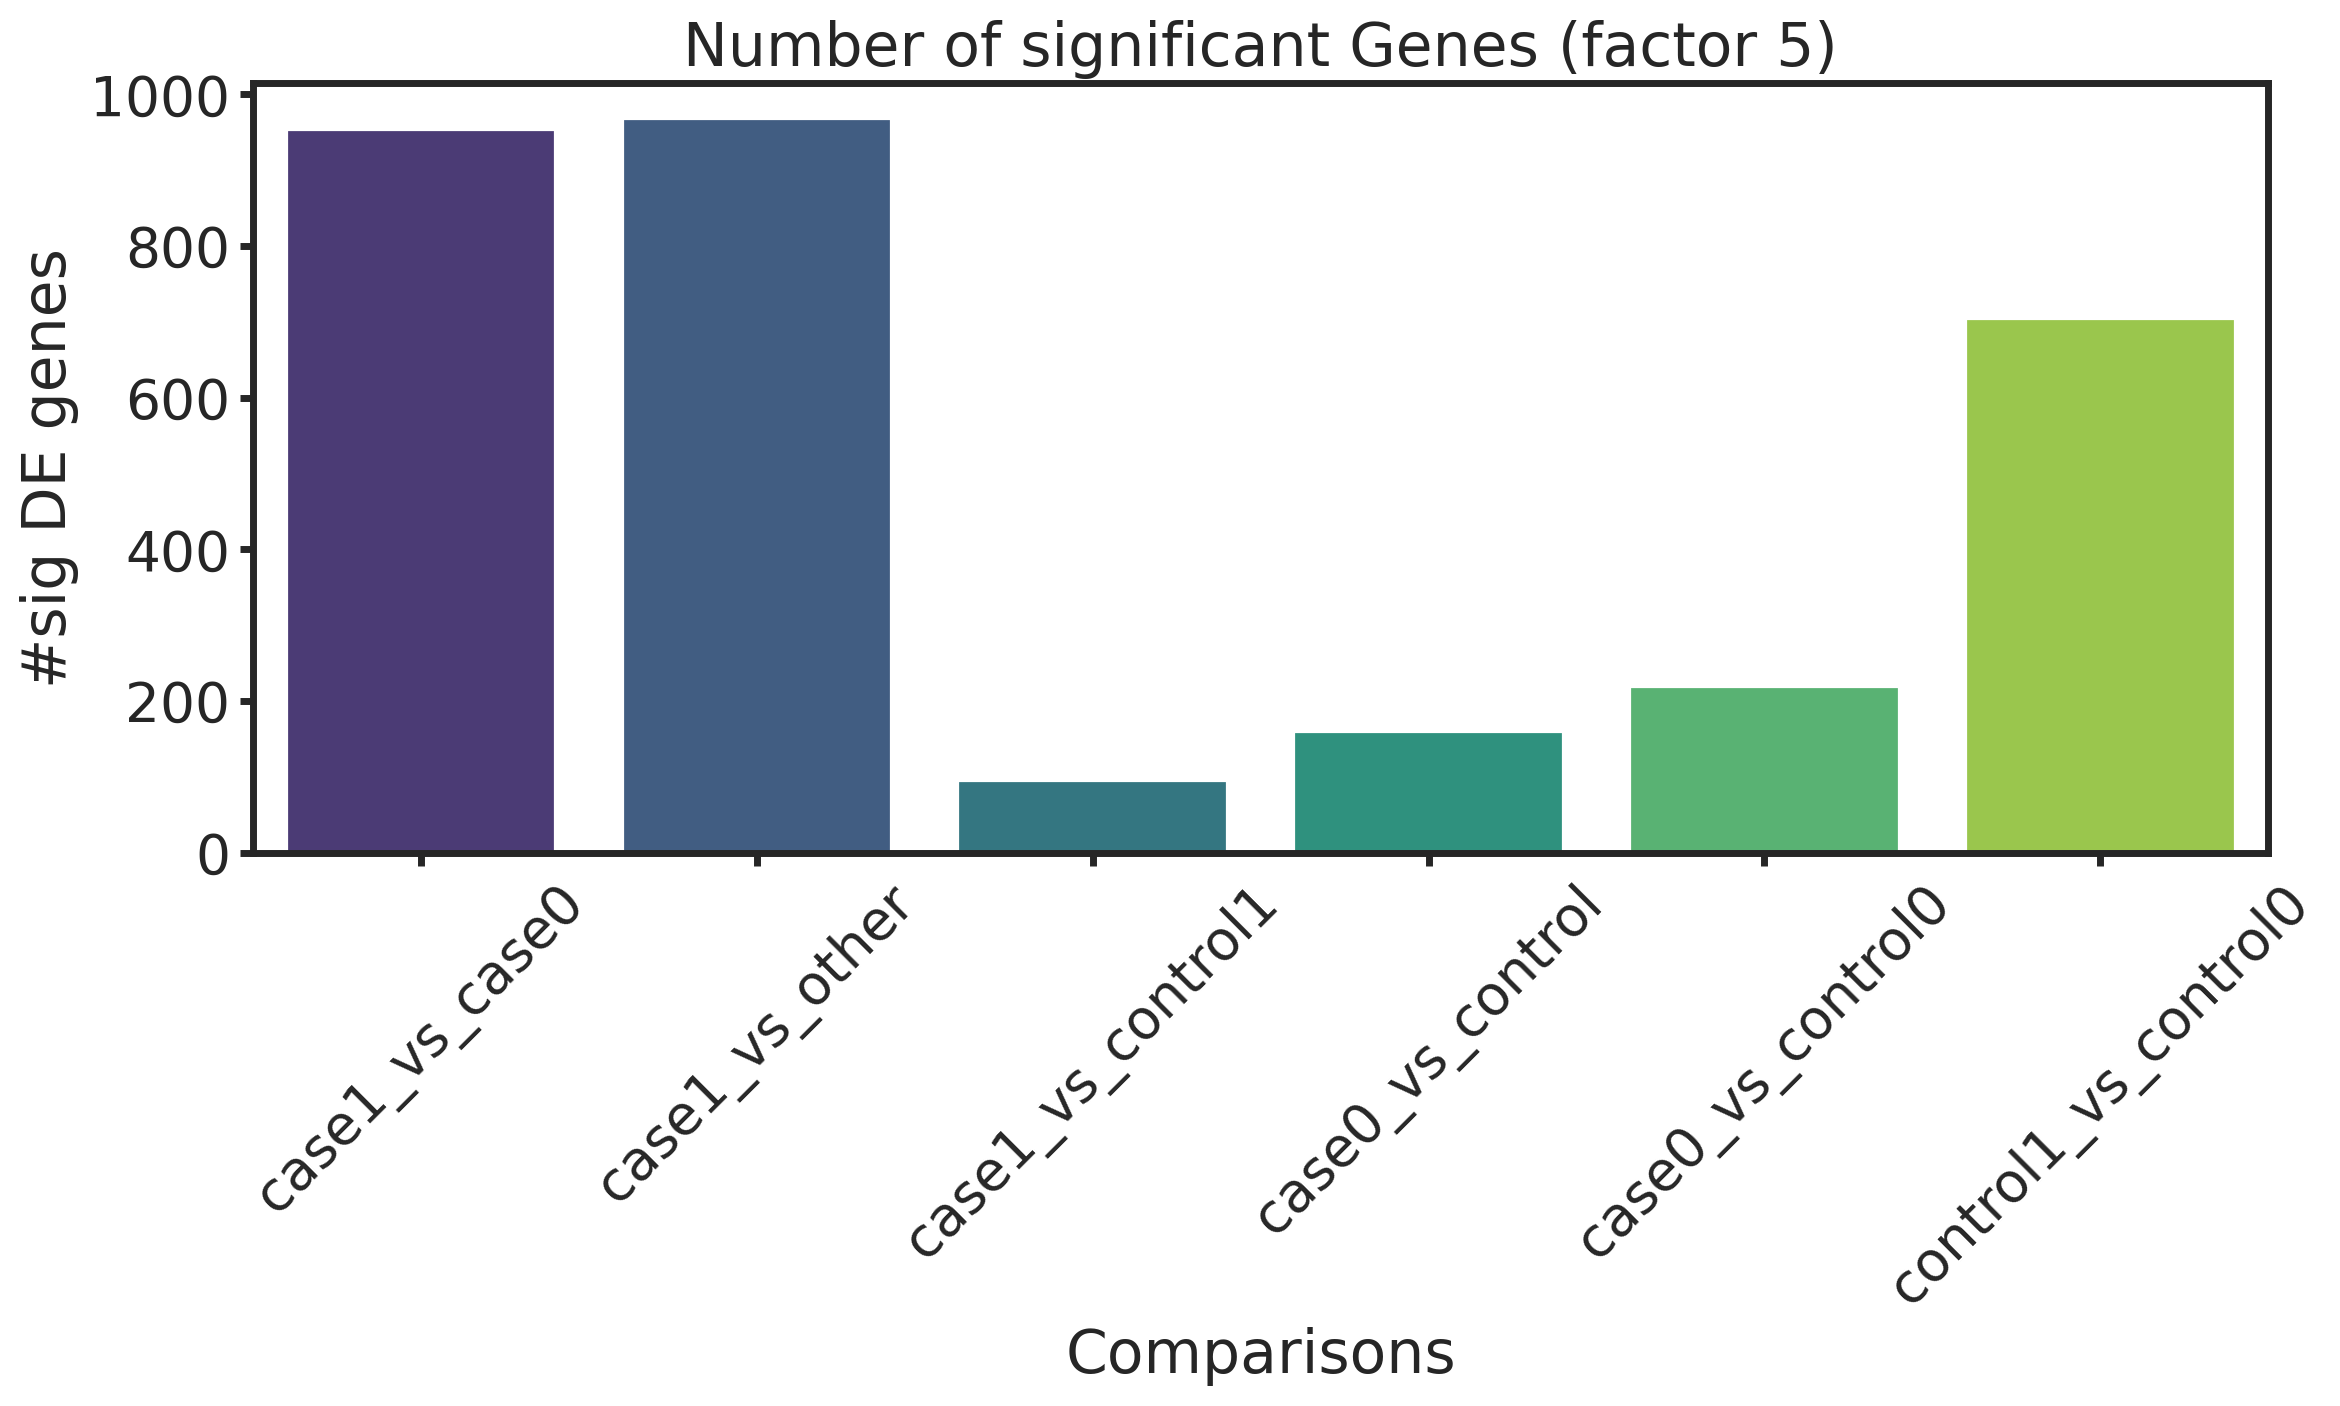

Factor 22


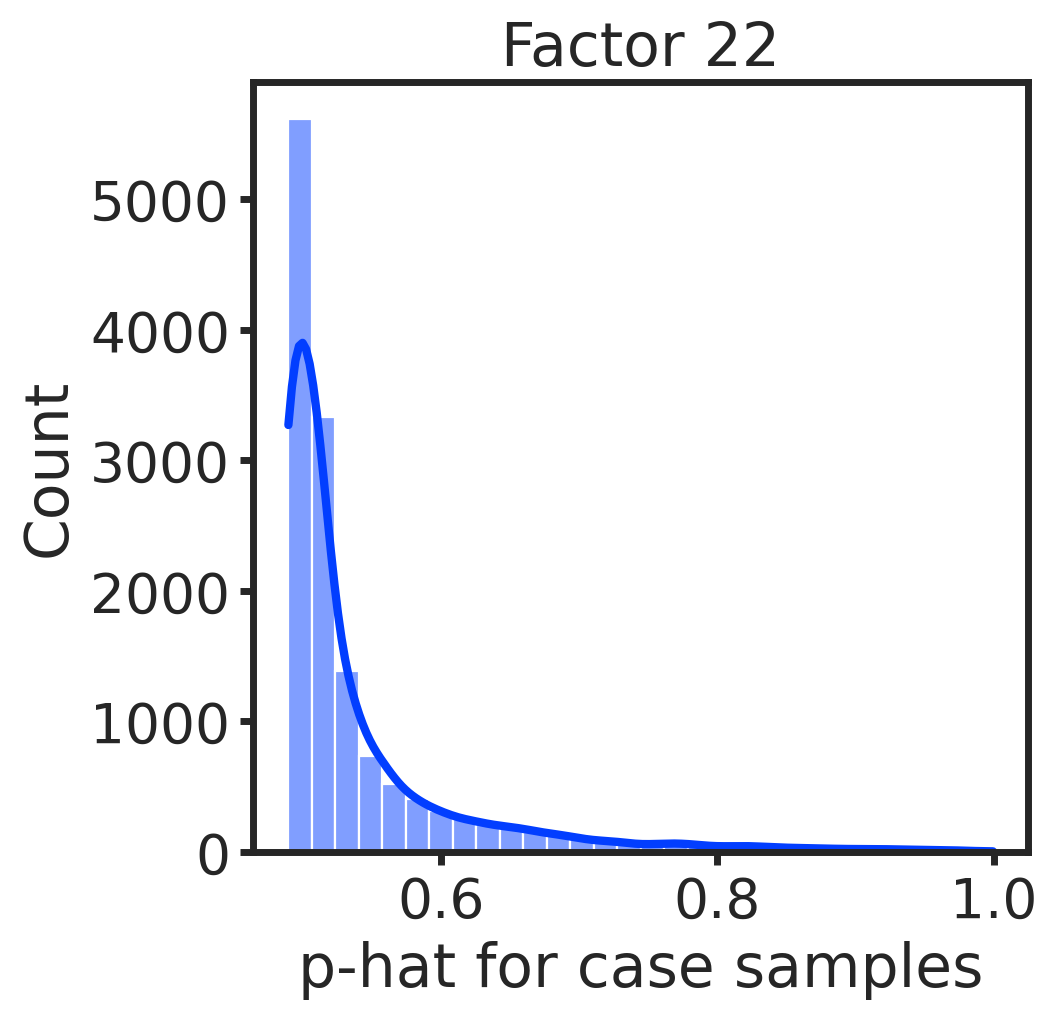

True
Centroids: [0.71462374 0.51592054]
Binarization Threshold: 0.6152721410342097
object
phat_cluster_factor22
case_0       12400
control_0    11765
case_1        1565
control_1      602
Name: count, dtype: int64


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000110375', 'ENSMUSG00000100162']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000041014  45.968           8.993  0.000      0.000      Nrg3
1   ENSMUSG00000055421  45.277           7.306  0.000      0.000     Pcdh9
2   ENSMUSG00000092341  40.931          23.497  0.000      0.000    Malat1
3   ENSMUSG00000021268  32.690           6.551  0.000      0.000      Meg3
4   ENSMUSG00000044349  27.075           3.303  0.000      0.000    Snhg11
5   ENSMUSG00000119584  26.872          29.531  0.000      0.000     Rn18s
6   ENSMUSG00000025551  24.708           3.703  0.000      0.000     Fgf14
7   ENSMUSG00000052727  23.265           2.529  0.000      0.000     Map1b
8   ENSMUSG00000063142  22.944           3.811  0.000      0.000    Kcnma1
9   ENSMUSG00000064115  21.925           3.152  0.000      0.000     Cadm2
10  ENSMUSG00000047454  21.870           2.333  0.000      0.000      Gphn
11  ENSMUSG00000008658  21.645           4.405  0.000      0.000    Rbfox1
12  ENSMUSG00000040640  2

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000110375', 'ENSMUSG00000100162']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000041014  46.789           8.767  0.000      0.000      Nrg3
1   ENSMUSG00000055421  45.691           7.090  0.000      0.000     Pcdh9
2   ENSMUSG00000092341  45.495          25.039  0.000      0.000    Malat1
3   ENSMUSG00000119584  38.886          37.200  0.000      0.000     Rn18s
4   ENSMUSG00000021268  34.984           6.859  0.000      0.000      Meg3
5   ENSMUSG00000044349  28.233           3.389  0.000      0.000    Snhg11
6   ENSMUSG00000047454  26.915           2.843  0.000      0.000      Gphn
7   ENSMUSG00000025551  25.635           3.763  0.000      0.000     Fgf14
8   ENSMUSG00000052727  24.961           2.692  0.000      0.000     Map1b
9   ENSMUSG00000035202  24.528           2.577  0.000      0.000     Lars2
10  ENSMUSG00000022748  23.805           2.591  0.000      0.000     Cmss1
11  ENSMUSG00000039145  23.717           3.116  0.000      0.000    Camk1d
12  ENSMUSG00000063142  2

...

                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000119584  60.549          15.362  0.000      0.000     Rn18s
1   ENSMUSG00000022748  19.217           1.195  0.000      0.000     Cmss1
2   ENSMUSG00000047454  18.944           1.111  0.000      0.000      Gphn
3   ENSMUSG00000035202  17.129           0.936  0.000      0.000     Lars2
4   ENSMUSG00000039145  14.867           0.608  0.000      0.000    Camk1d
5   ENSMUSG00000092341  14.320           3.100  0.000      0.000    Malat1
6   ENSMUSG00000113136   8.591           0.707  0.000      0.000   Gm19951
7   ENSMUSG00000028649   6.566           0.711  0.000      0.000     Macf1
8   ENSMUSG00000061080   6.527           0.966  0.000      0.000     Lsamp
9   ENSMUSG00000096054   5.575           0.561  0.000      0.000     Syne1
10  ENSMUSG00000026131   5.238           0.649  0.000      0.000       Dst
11  ENSMUSG00000040003   5.211           0.653  0.000      0.000     Magi2
12  ENSMUSG00000060882   

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000119584  61.765          15.823  0.000      0.000     Rn18s
1   ENSMUSG00000047454  20.029           1.192  0.000      0.000      Gphn
2   ENSMUSG00000022748  20.029           1.265  0.000      0.000     Cmss1
3   ENSMUSG00000035202  17.964           1.014  0.000      0.000     Lars2
4   ENSMUSG00000092341  17.784           3.681  0.000      0.000    Malat1
5   ENSMUSG00000039145  16.476           0.728  0.000      0.000    Camk1d
6   ENSMUSG00000113136   8.815           0.749  0.000      0.000   Gm19951
7   ENSMUSG00000061080   8.240           1.215  0.000      0.000     Lsamp
8   ENSMUSG00000021268   7.624           0.945  0.000      0.000      Meg3
9   ENSMUSG00000028649   7.268           0.832  0.000      0.000     Macf1
10  ENSMUSG00000096054   6.648           0.708  0.000      0.000     Syne1
11  ENSMUSG00000040003   6.415           0.817  0.000      0.000     Magi2
12  ENSMUSG00000020524   

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000100162', 'ENSMUSG00000098243', 'ENSMUSG00000110375']
/tmp/ipykernel_1414540/1374827707.py:349: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparisons, y=sig_de_counts, palette="viridis")


-----------------------------------
Control1 vs Control0
                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000041014  28.949           7.675  0.000      0.000      Nrg3
1   ENSMUSG00000055421  28.061           6.819  0.000      0.000     Pcdh9
2   ENSMUSG00000092341  24.161          11.709  0.000      0.000    Malat1
3   ENSMUSG00000021268  21.867           5.537  0.000      0.000      Meg3
4   ENSMUSG00000044349  17.053           2.822  0.000      0.000    Snhg11
5   ENSMUSG00000036438  15.819           3.350  0.000      0.000     Calm2
6   ENSMUSG00000027273  15.000           3.107  0.000      0.000    Snap25
7   ENSMUSG00000026576  14.980           2.706  0.000      0.000    Atp1b1
8   ENSMUSG00000119584  14.485           9.439  0.000      0.000     Rn18s
9   ENSMUSG00000035864  14.388           2.573  0.000      0.000      Syt1
10  ENSMUSG00000008658  13.213           3.306  0.000      0.000    Rbfox1
11  ENSMUSG00000052727  13.181           2.

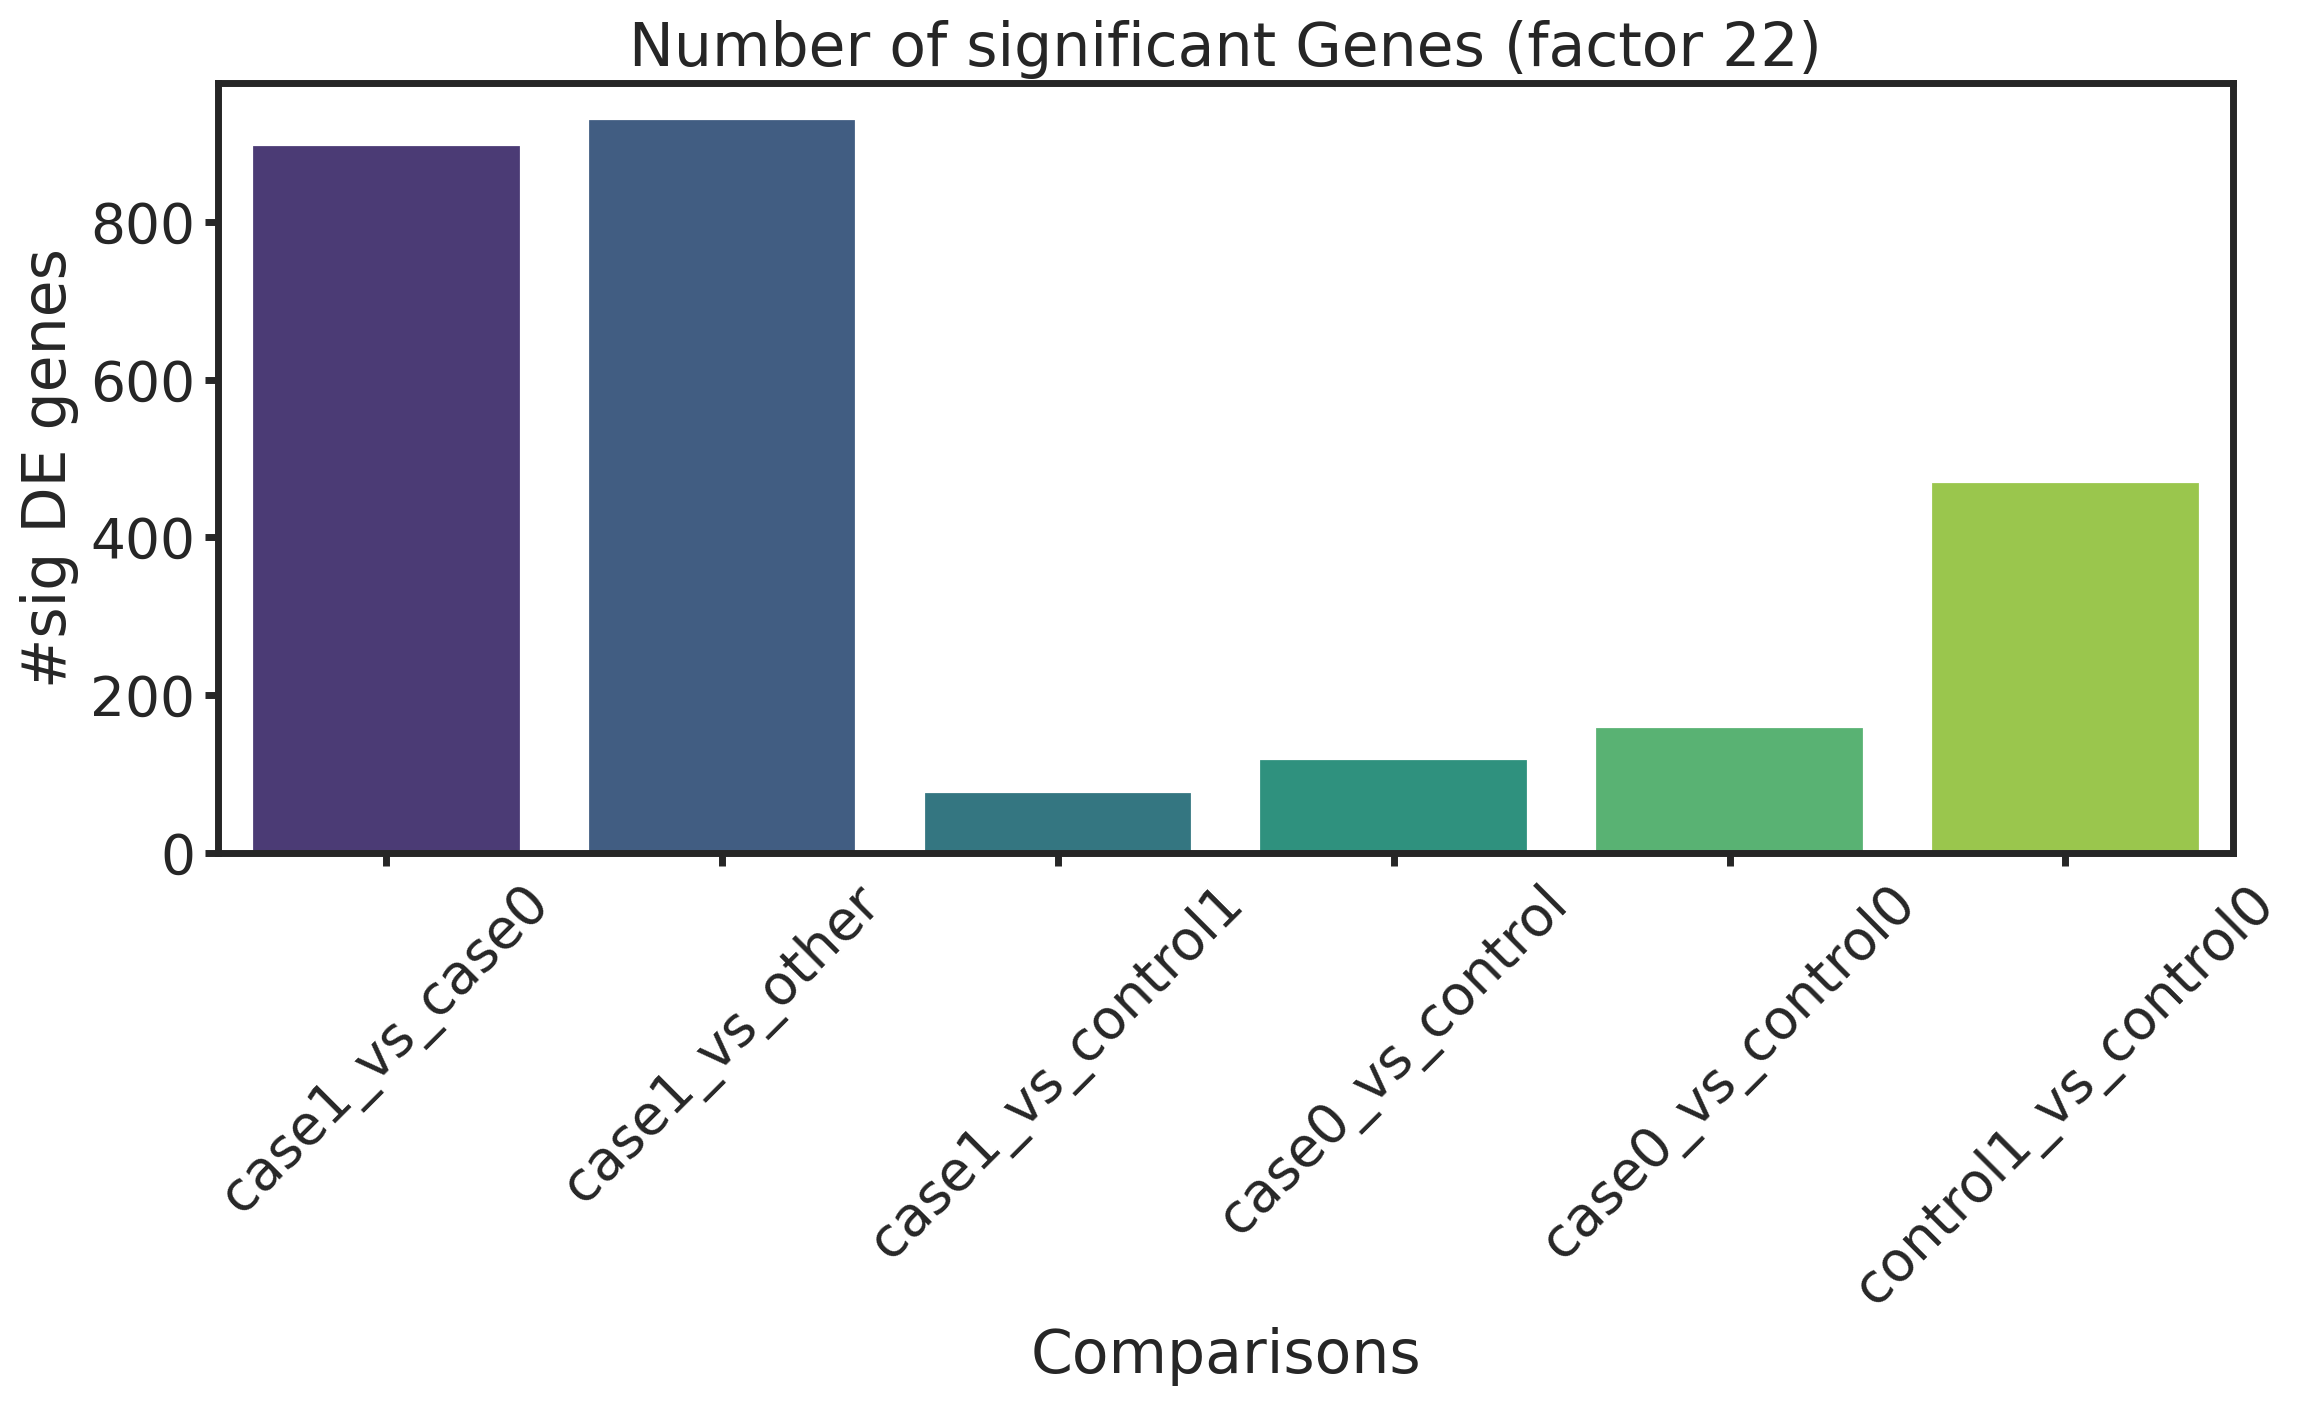

Factor 3


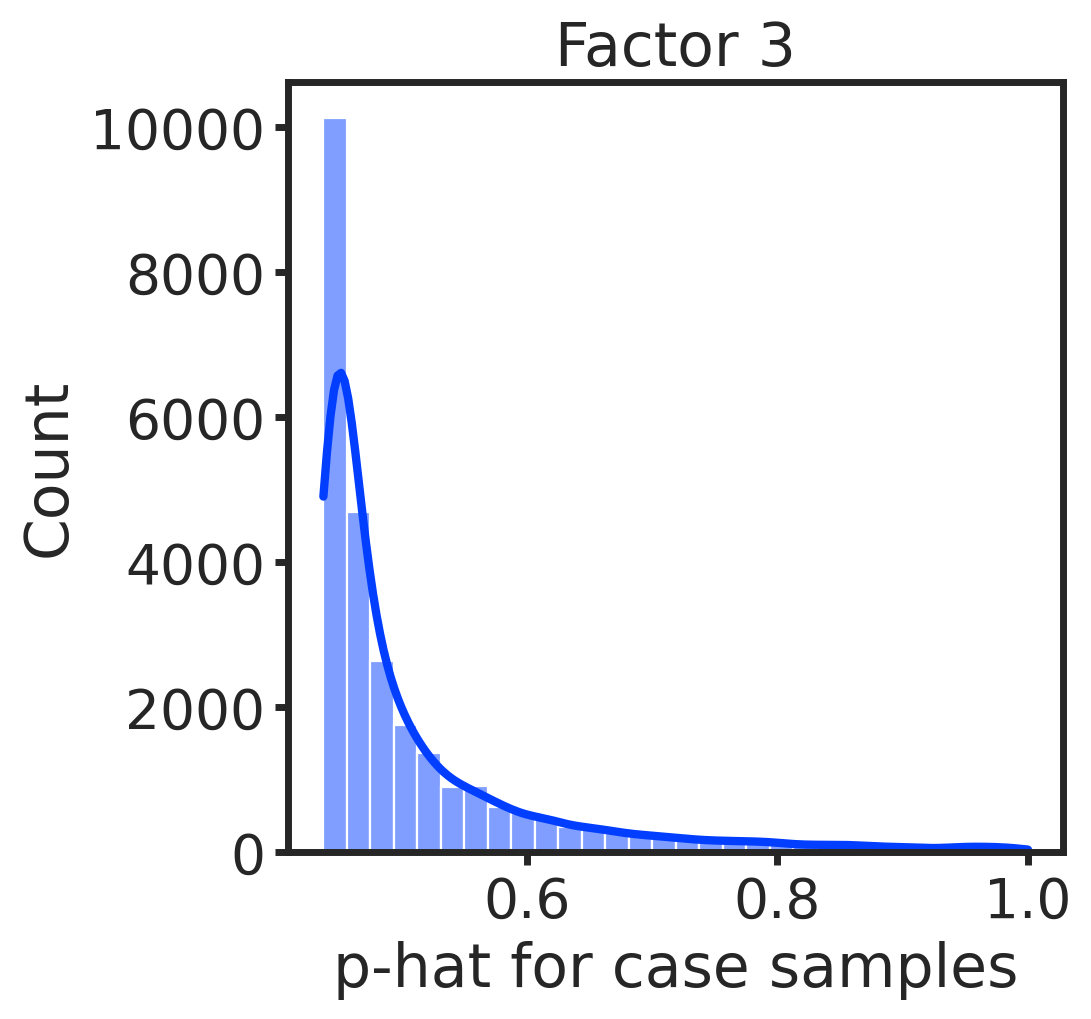

True
Centroids: [0.47627009 0.7255162 ]
Binarization Threshold: 0.6008931441231303
object
phat_cluster_factor3
control_0    26057
case_0       23382
case_1        3497
control_1     1365
Name: count, dtype: int64


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000092341  95.488          35.653  0.000      0.000    Malat1
1   ENSMUSG00000119584  46.919          32.625  0.000      0.000     Rn18s
2   ENSMUSG00000021268  44.673           6.415  0.000      0.000      Meg3
3   ENSMUSG00000033981  43.780           3.585  0.000      0.000     Gria2
4   ENSMUSG00000061080  42.840           5.689  0.000      0.000     Lsamp
5   ENSMUSG00000064115  39.639           4.189  0.000      0.000     Cadm2
6   ENSMUSG00000028161  39.496           5.078  0.000      0.000    Ppp3ca
7   ENSMUSG00000002107  39.300           4.691  0.000      0.000     Celf2
8   ENSMUSG00000055421  38.882           3.808  0.000      0.000     Pcdh9
9   ENSMUSG00000008658  37.885           5.155  0.000      0.000    Rbfox1
10  ENSMUSG00000052572  37.771           4.934  0.000      0.000      Dlg2
11  ENSMUSG00000047454  37.435           2.806  0.000      0.000      Gphn
12  ENSMUSG00000020524  3

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000092341  97.034          35.286  0.000      0.000    Malat1
1   ENSMUSG00000119584  64.056          39.465  0.000      0.000     Rn18s
2   ENSMUSG00000021268  47.585           6.588  0.000      0.000      Meg3
3   ENSMUSG00000061080  45.124           5.814  0.000      0.000     Lsamp
4   ENSMUSG00000047454  43.994           3.232  0.000      0.000      Gphn
5   ENSMUSG00000033981  43.486           3.310  0.000      0.000     Gria2
6   ENSMUSG00000064115  40.701           4.114  0.000      0.000     Cadm2
7   ENSMUSG00000055421  40.562           3.883  0.000      0.000     Pcdh9
8   ENSMUSG00000002107  40.459           4.609  0.000      0.000     Celf2
9   ENSMUSG00000039145  39.869           3.197  0.000      0.000    Camk1d
10  ENSMUSG00000008658  39.751           5.305  0.000      0.000    Rbfox1
11  ENSMUSG00000052572  39.340           4.973  0.000      0.000      Dlg2
12  ENSMUSG00000035202  3

...

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000119584  81.103          13.400  0.000      0.000     Rn18s
1   ENSMUSG00000022748  24.014           1.152  0.000      0.000     Cmss1
2   ENSMUSG00000047454  23.731           0.993  0.000      0.000      Gphn
3   ENSMUSG00000035202  19.892           0.776  0.000      0.000     Lars2
4   ENSMUSG00000039145  19.764           0.587  0.000      0.000    Camk1d
5   ENSMUSG00000092341  11.595           0.701  0.000      0.000    Malat1
6   ENSMUSG00000113136  10.248           0.692  0.000      0.000   Gm19951
7   ENSMUSG00000007891   9.404           1.999  0.000      0.000      Ctsd
8   ENSMUSG00000021268   8.363           0.652  0.000      0.000      Meg3
9   ENSMUSG00000052727   6.875           0.391  0.000      0.000     Map1b
10  ENSMUSG00000028649   6.356           0.571  0.000      0.000     Macf1
11  ENSMUSG00000061080   6.355           0.731  0.000      0.000     Lsamp
12  ENSMUSG00000026728   

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000100162', 'ENSMUSG00000098243', 'ENSMUSG00000110375']


-----------------------------------
Control1 vs Control0
                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000092341  62.355          26.591  0.000      0.000    Malat1
1   ENSMUSG00000119584  29.941          14.461  0.000      0.000     Rn18s
2   ENSMUSG00000028161  27.440           6.403  0.000      0.000    Ppp3ca
3   ENSMUSG00000061080  26.650           4.831  0.000      0.000     Lsamp
4   ENSMUSG00000033981  25.996           3.495  0.000      0.000     Gria2
5   ENSMUSG00000036438  25.335           3.878  0.000      0.000     Calm2
6   ENSMUSG00000064115  24.437           3.653  0.000      0.000     Cadm2
7   ENSMUSG00000021268  24.266           4.994  0.000      0.000      Meg3
8   ENSMUSG00000049775  23.934           2.656  0.000      0.000    Tmsb4x
9   ENSMUSG00000039145  23.774           3.094  0.000      0.000    Camk1d
10  ENSMUSG00000022708  23.361           3.561  0.000      0.000    Zbtb20
11  ENSMUSG00000002107  23.361           3.

/tmp/ipykernel_1414540/1374827707.py:349: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparisons, y=sig_de_counts, palette="viridis")


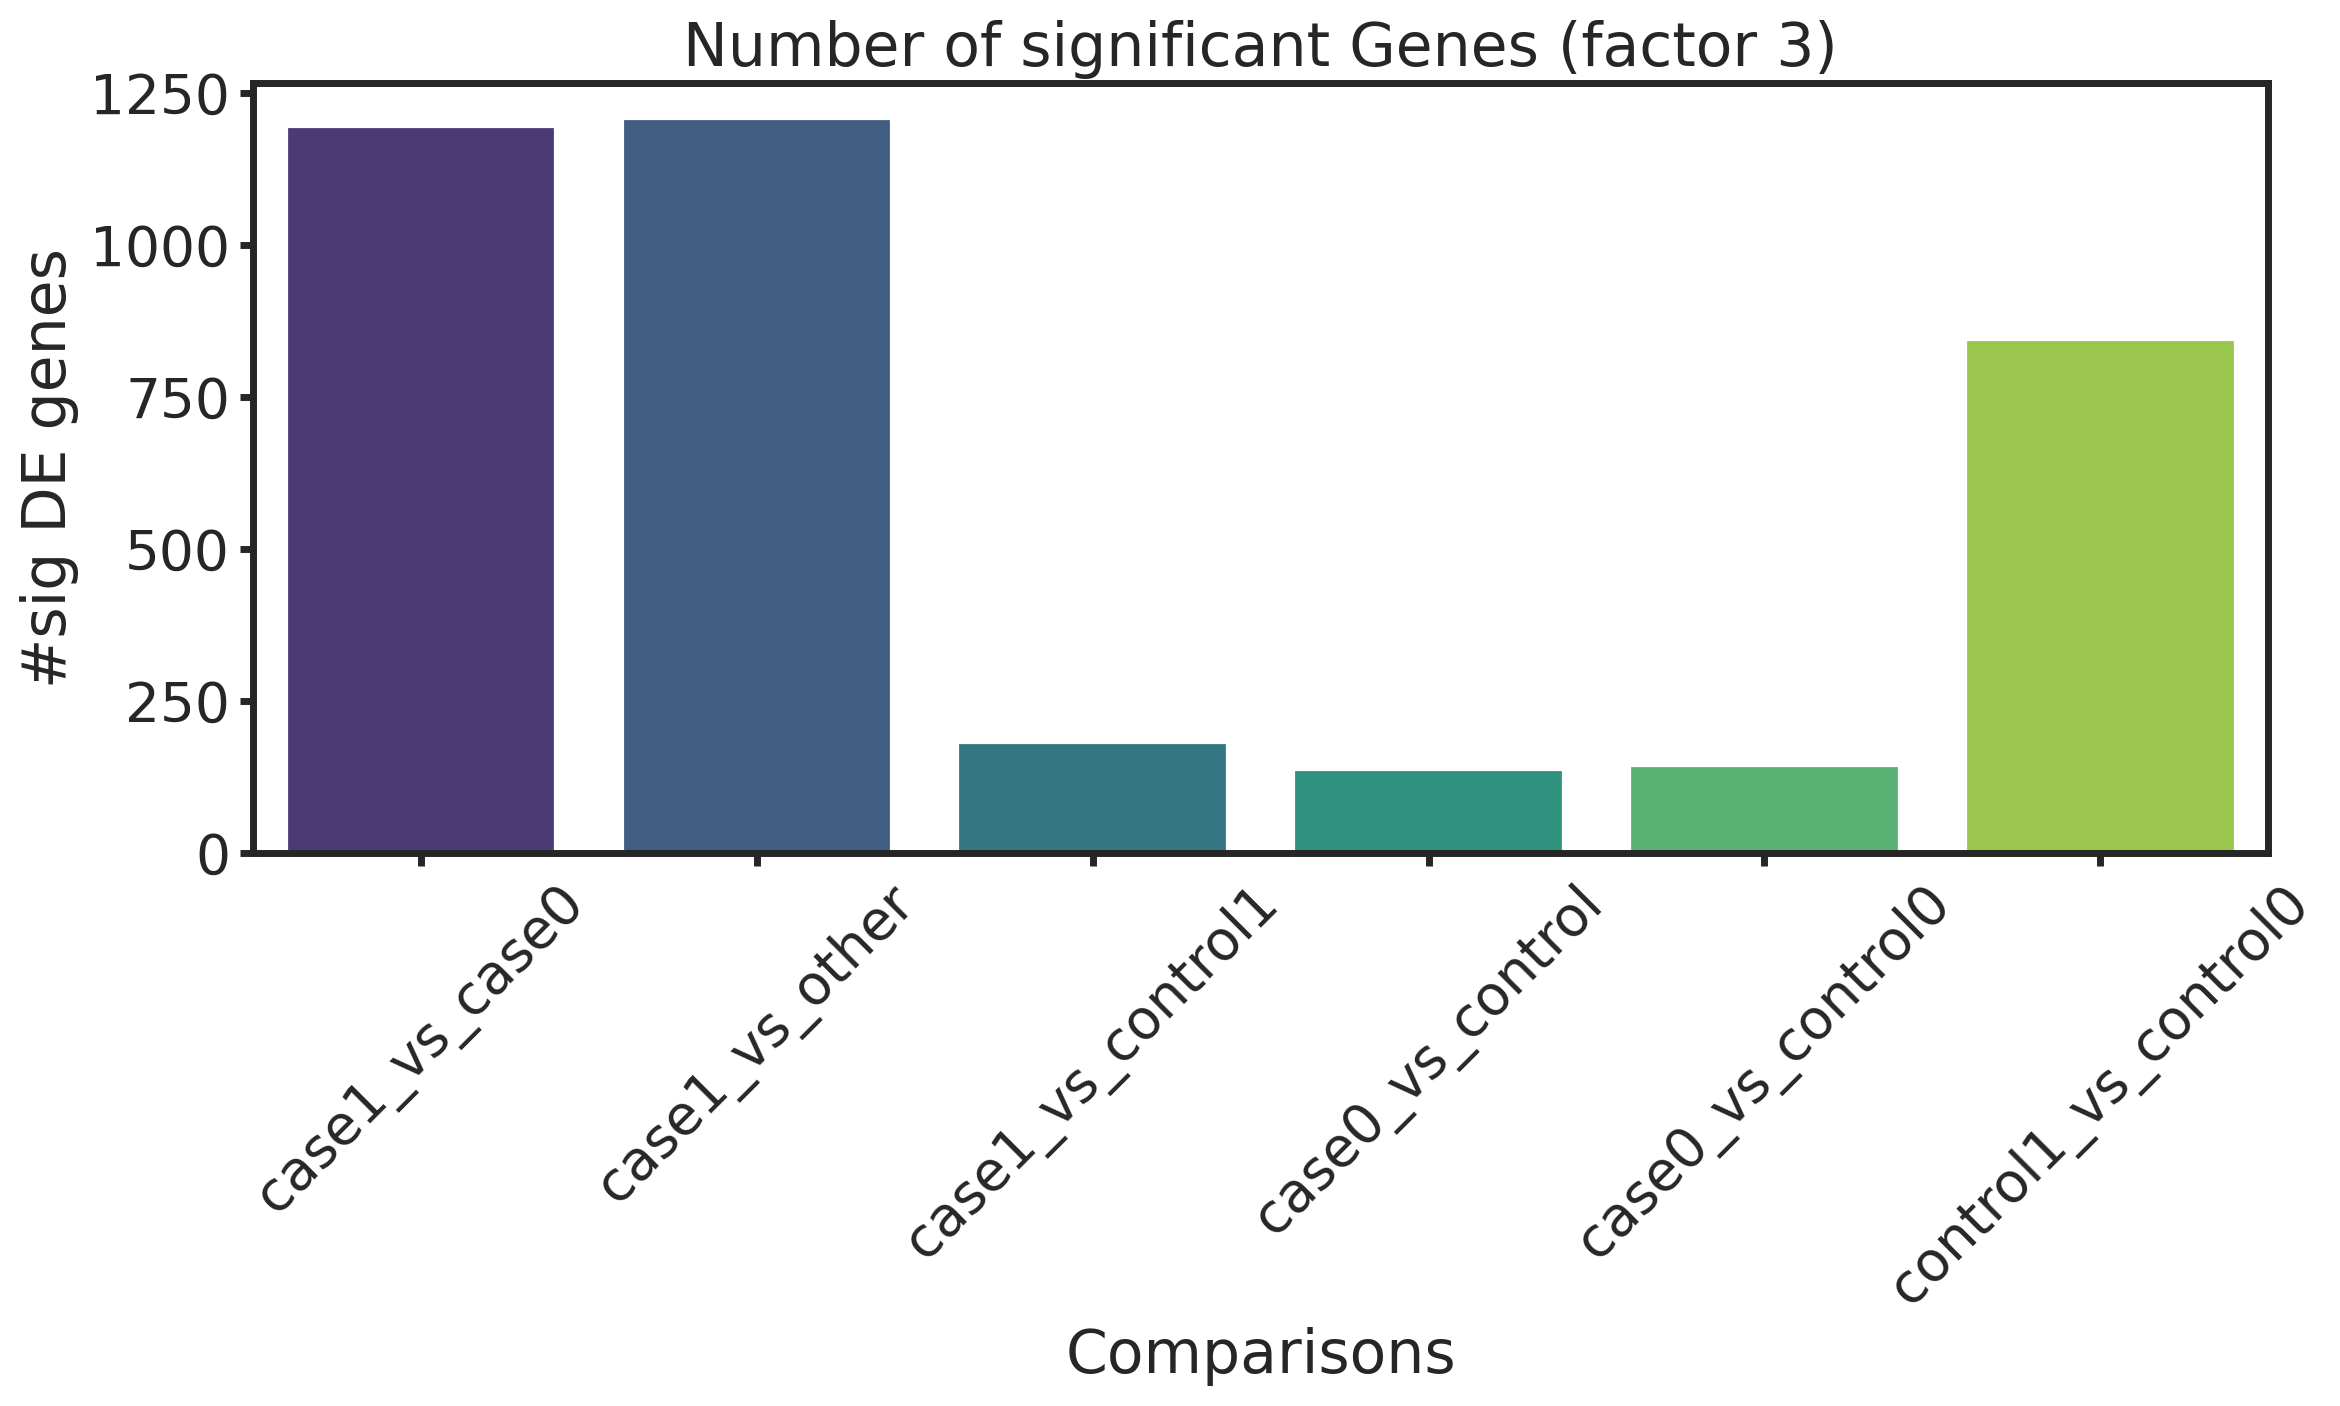

Factor 12


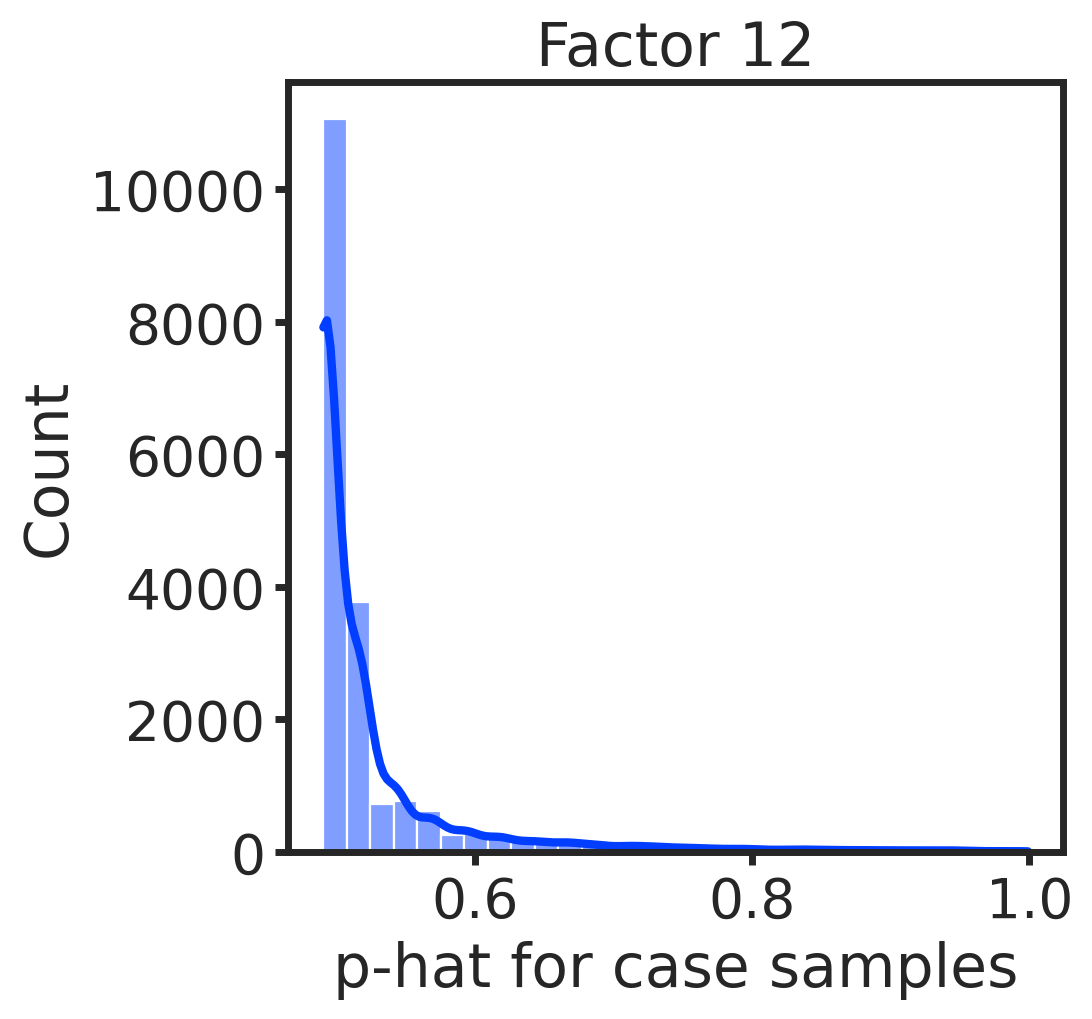

True
Centroids: [0.50745582 0.71586768]
Binarization Threshold: 0.6116617534132462
object
phat_cluster_factor12
case_0       17472
control_0    17088
case_1        1480
control_1      588
Name: count, dtype: int64


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000061080  63.937          14.774  0.000      0.000     Lsamp
1   ENSMUSG00000092341  47.063          27.118  0.000      0.000    Malat1
2   ENSMUSG00000021268  35.698           6.786  0.000      0.000      Meg3
3   ENSMUSG00000064115  33.003           4.828  0.000      0.000     Cadm2
4   ENSMUSG00000008658  30.733           6.147  0.000      0.000    Rbfox1
5   ENSMUSG00000033981  28.910           3.401  0.000      0.000     Gria2
6   ENSMUSG00000044349  26.953           3.365  0.000      0.000    Snhg11
7   ENSMUSG00000002107  26.302           4.297  0.000      0.000     Celf2
8   ENSMUSG00000003279  26.253           3.925  0.000      0.000    Dlgap1
9   ENSMUSG00000052727  25.846           2.989  0.000      0.000     Map1b
10  ENSMUSG00000028161  25.180           5.487  0.000      0.000    Ppp3ca
11  ENSMUSG00000061751  25.132           4.064  0.000      0.000     Kalrn
12  ENSMUSG00000119584  2

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000061080  64.346          14.520  0.000      0.000     Lsamp
1   ENSMUSG00000092341  50.444          28.293  0.000      0.000    Malat1
2   ENSMUSG00000021268  38.114           7.162  0.000      0.000      Meg3
3   ENSMUSG00000119584  36.613          36.330  0.000      0.000     Rn18s
4   ENSMUSG00000064115  34.181           4.953  0.000      0.000     Cadm2
5   ENSMUSG00000008658  32.272           6.467  0.000      0.000    Rbfox1
6   ENSMUSG00000033981  29.234           3.350  0.000      0.000     Gria2
7   ENSMUSG00000044349  28.382           3.546  0.000      0.000    Snhg11
8   ENSMUSG00000052727  27.624           3.195  0.000      0.000     Map1b
9   ENSMUSG00000002107  27.419           4.474  0.000      0.000     Celf2
10  ENSMUSG00000003279  27.056           4.049  0.000      0.000    Dlgap1
11  ENSMUSG00000020524  26.164           3.937  0.000      0.000     Gria1
12  ENSMUSG00000061751  2

...

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000100162', 'ENSMUSG00000110375']


                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000119584  69.550          15.120  0.000      0.000     Rn18s
1   ENSMUSG00000047454  22.754           1.175  0.000      0.000      Gphn
2   ENSMUSG00000022748  21.337           1.257  0.000      0.000     Cmss1
3   ENSMUSG00000039145  19.942           0.799  0.000      0.000    Camk1d
4   ENSMUSG00000035202  19.712           0.959  0.000      0.000     Lars2
5   ENSMUSG00000092341  16.367           2.925  0.000      0.000    Malat1
6   ENSMUSG00000021268  10.782           1.008  0.000      0.000      Meg3
7   ENSMUSG00000113136   9.498           0.799  0.000      0.000   Gm19951
8   ENSMUSG00000052727   8.039           0.532  0.000      0.000     Map1b
9   ENSMUSG00000096054   7.474           0.801  0.000      0.000     Syne1
10  ENSMUSG00000028649   7.422           0.732  0.000      0.000     Macf1
11  ENSMUSG00000026131   6.783           0.905  0.000      0.000       Dst
12  ENSMUSG00000008658   

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found no hit:	['ENSMUSG00000103428', 'ENSMUSG00000098243', 'ENSMUSG00000110375', 'ENSMUSG00000100162']


-----------------------------------
Control1 vs Control0
                  gene  scores  logfoldchanges  pvals  pvals_adj gene_name
0   ENSMUSG00000061080  41.283          12.636  0.000      0.000     Lsamp
1   ENSMUSG00000092341  31.352          16.205  0.000      0.000    Malat1
2   ENSMUSG00000021268  21.162           5.153  0.000      0.000      Meg3
3   ENSMUSG00000064115  19.258           4.149  0.000      0.000     Cadm2
4   ENSMUSG00000008658  18.526           4.726  0.000      0.000    Rbfox1
5   ENSMUSG00000028161  18.033           6.326  0.000      0.000    Ppp3ca
6   ENSMUSG00000033981  17.450           3.135  0.000      0.000     Gria2
7   ENSMUSG00000036438  15.985           3.655  0.000      0.000     Calm2
8   ENSMUSG00000028785  15.747           3.904  0.000      0.000      Hpca
9   ENSMUSG00000044349  15.234           2.985  0.000      0.000    Snhg11
10  ENSMUSG00000026833  15.225           3.054  0.000      0.000     Olfm1
11  ENSMUSG00000061751  15.194           3.

/tmp/ipykernel_1414540/1374827707.py:349: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparisons, y=sig_de_counts, palette="viridis")


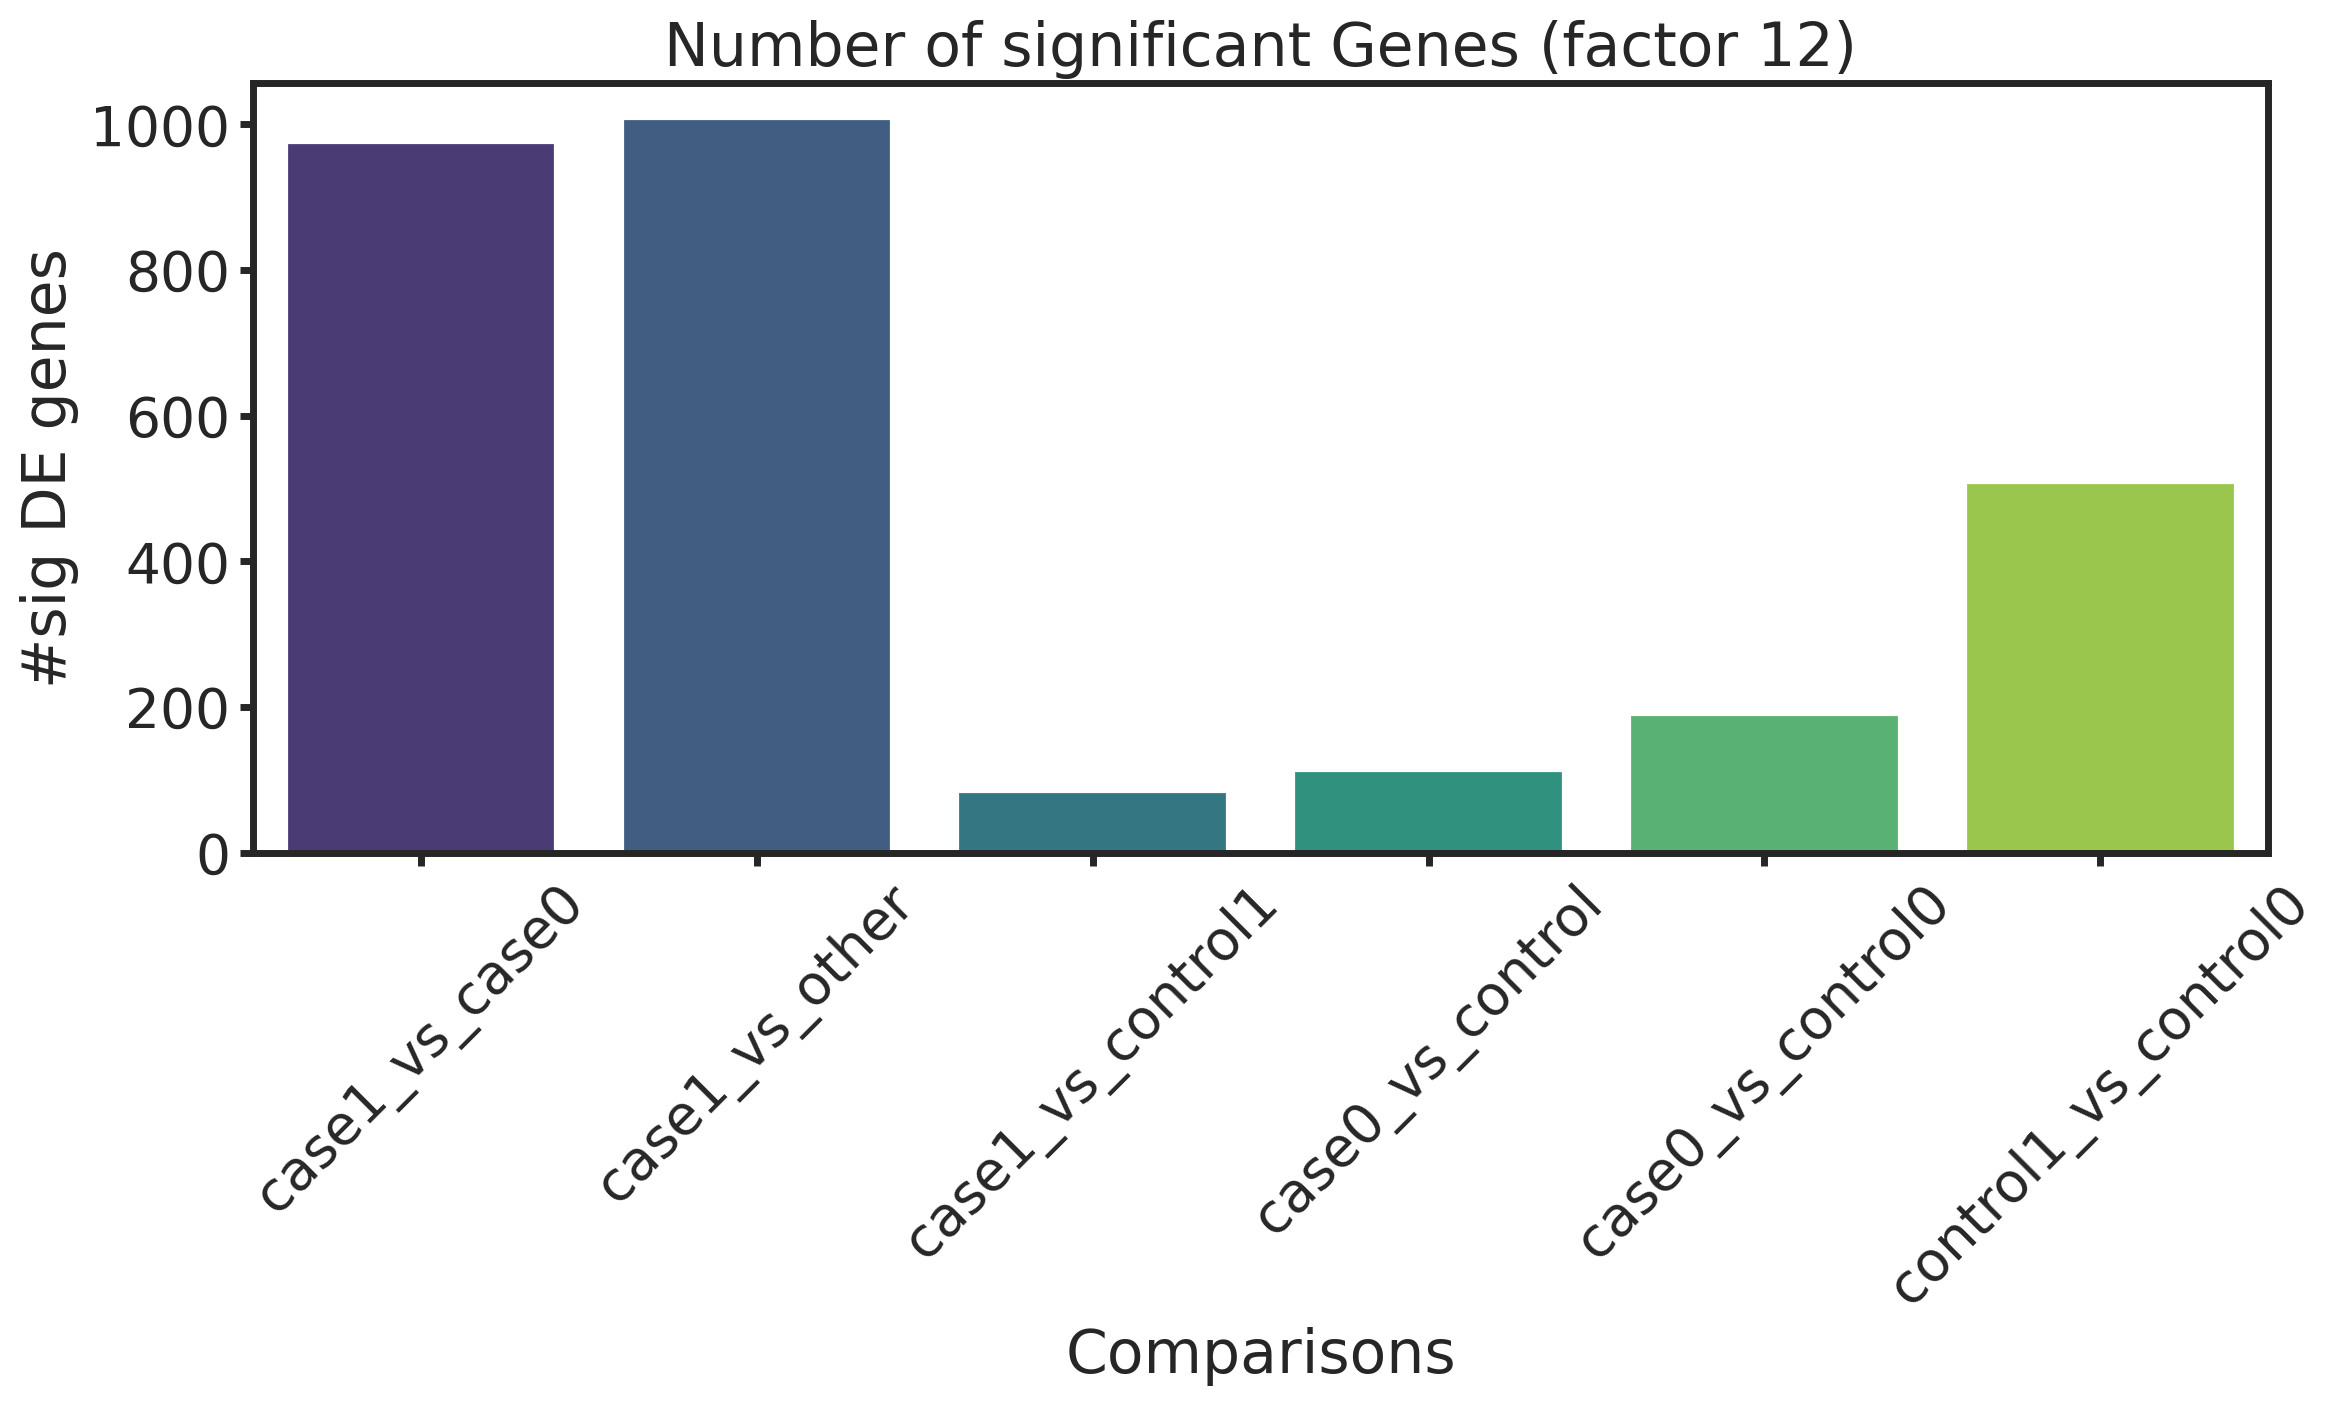

In [ ]:

### a dictionary to store the DE results for each comparison and each factor (dict of dicts: outer dict key is factor index, inner dict key is comparison name, inner dict value is DE results dataframe)
### for each factor, we will have a dictionary of DE results for each comparison (case1 vs case0, case1 vs other, case1 vs control1, case0 vs control, case0 vs control0, control1 vs control0)
de_results_dict_factorwise = {}

for factor_idx in t3_gof_control12_18: #range(min(max_factors, X.shape[1])) ,3, 6, 19,
    
    print(f"Factor {factor_idx+1}")
    result = results[factor_idx]
    p_hat_factor = result['p_hat']
    if 'high_cluster_indices' in result:
        high_cluster_indices = result['high_cluster_indices']
    else:
        high_cluster_indices = np.arange(adata.n_obs)
    
    adata_sub = adata[high_cluster_indices].copy()

    p_hat_factor_case = p_hat_factor[adata_sub.obs['Condition'] == CASE_COND_NAME]
    p_hat_factor_case_df = pd.DataFrame(p_hat_factor_case, columns=['p_hat'])
    
    plt.figure(figsize=(5, 5))
    sns.histplot(p_hat_factor_case_df['p_hat'], bins=30, kde=True)
    plt.title(f"Factor {factor_idx+1}")
    plt.xlabel("p-hat for case samples")
    plt.ylabel("Count")
    plt.show()

    ##### we will first cluster the phat scores 
    
    kmeans = KMeans(n_clusters=2, random_state=RAND_SEED)
    kmeans.fit(p_hat_factor_case.reshape(-1, 1))

    ### add cluster information to adata - to the case observations with the correct order
    mask_case = (adata_sub.obs['Condition'].values == CASE_COND_NAME)
    

    # Sanity check: lengths must match
    print(mask_case.sum() == len(kmeans.labels_))

    # Remap labels so that 1 = higher p-hat, 0 = lower p-hat
    centers = kmeans.cluster_centers_.ravel()
    order = np.argsort(centers)               # [low_center_label, high_center_label]
    remap = {order[0]: 0, order[1]: 1}
    labels_remapped = np.vectorize(remap.get)(kmeans.labels_).astype(int)

    # Calculate the threshold as the midpoint between the centroids
    threshold = np.mean(centers)
    print(f"Centroids: {centers.flatten()}")
    print(f"Binarization Threshold: {threshold}")

    #### here we are converting case-cluster labels to case-0 and case-1 (based on mean phat)
    #### we then asign control labels to each spot which is neither case-0 or 1

    # Create an obs column name that encodes which factor you clustered (here factor 7)
    obs_col = 'phat_cluster_factor' + str(factor_idx+1)
    ### score the p-hat values for all cells
    adata_sub.obs['phat_factor'+str(factor_idx+1)] = result['p_hat']

    # Initialize with NaN for all, then fill case rows in-place to preserve order
    adata_sub.obs[obs_col] = np.nan
    adata_sub.obs.loc[mask_case, obs_col] = labels_remapped

    # make it categorical and store centers for reference
    adata_sub.obs[obs_col] = pd.Categorical(adata_sub.obs[obs_col], categories=[0, 1])
    ### convert to string
    adata_sub.obs[obs_col] = adata_sub.obs[obs_col].astype(str)
    ## add 'case' to the obs_col values
    adata_sub.obs[obs_col] = adata_sub.obs[obs_col].apply(lambda x: x if pd.isna(x) else 'case_' + str(x))
    ## replace case_nan with control
    adata_sub.obs[obs_col] = adata_sub.obs[obs_col].replace('case_nan', 'control')
    ### visualize p-hat scores over cluster 0 and 1 as violin plot

    ###### here we are splitting the control cluster to control_0 and control_1 based on the threshold derived from case samples
    ### split the obs_col values equal to 'case_nan' into 'control_0' and 'control_1' based on the threshold derived from case samples
    def assign_control_label(row):
        ### this function uses global variable obs_col which changes in each interation of the loop - don't move it out
        if row[obs_col].startswith('case_0') or row[obs_col].startswith('case_1'):
            return row[obs_col]
        else:
            if row['phat_factor'+str(factor_idx+1)] >= threshold:
                return 'control_1'
            else:
                return 'control_0'


    adata_sub.obs[obs_col] = adata_sub.obs.apply(assign_control_label, axis=1)
    
    ## check if the obs_col values are string
    print(adata_sub.obs[obs_col].dtype)
    cluster_mask_dict[obs_col] = adata_sub.obs[obs_col]

    ### make it categorical
    adata_sub.obs[obs_col] = pd.Categorical(adata_sub.obs[obs_col], categories=['control_0', 'control_1', 'case_0', 'case_1'])
    adata_sub.obs[obs_col] = adata_sub.obs[obs_col].astype(str)
    ## check the stats of each cluster
    print(adata_sub.obs[obs_col].value_counts())

    ###############################################################################
    ####### we then start performing DE between different clusters 
    # (case-1 vs case-0, case-1 vs all other, case-1 vs control_1, case-0 vs all control, case-0 vs control_0, control_1 vs control_0)
    num_sig_DE = {}
    de_results_dict = {}
    ###############################################################################
    ### perform DE between case-0 and case-1
    case_1_mask = (adata_sub.obs[obs_col] == 'case_1').values
    case_0_mask = (adata_sub.obs[obs_col] == 'case_0').values
    # Subset to the two clusters
    keep = case_1_mask | case_0_mask
    ad = adata_sub[keep].copy()
    # Temporary 2-level group label
    grp_col = "_tmp_de_group"
    ad.obs[grp_col] = pd.Categorical(
        np.where(case_1_mask[keep], "case1", "case0"),
        categories=["case0", "case1"]
    )
    # Wilcoxon DE: case1 vs case0
    sc.tl.rank_genes_groups(
        ad,
        groupby=grp_col,
        groups=["case1"],
        reference="case0",
        method="wilcoxon",
        corr_method="benjamini-hochberg",
        use_raw=False,   
        layer=None,      
        n_genes=ad.n_vars
    )
    de_results = sc.get.rank_genes_groups_df(ad, group="case1").rename(columns={"names": "gene"})
    # score column: Z-statistic (standardized Wilcoxon rank-sum score) computed for each gene after comparing expression ranks between groups.    
    gene_names = hlps.map_ensembl_to_symbol(de_results.gene.tolist(), species='mouse')
    de_results['gene_name'] = de_results['gene'].map(gene_names)
    print(de_results.head(20))
    num_sig_DE['case1_vs_case0'] = get_num_sig_de(de_results, fdr_threshold=0.05, logfc_threshold=0.1)
    print(f"Number of significant DE genes (case1 vs case0): {num_sig_DE['case1_vs_case0']}")
    de_results_dict['case1_vs_case0'] = de_results

    ###############################################################################
    ### perform DE between case-1 and [control+case-0] 
    case_1_mask = (adata_sub.obs[obs_col] == 'case_1').values
    case_0_mask = (adata_sub.obs[obs_col] == 'case_0').values
    control_mask = (adata_sub.obs['Condition'].values != CASE_COND_NAME)
    # Subset to the two clusters + control
    keep = case_1_mask | case_0_mask | control_mask
    ad = adata_sub[keep].copy()
    # Temporary 2-level group label
    grp_col = "_tmp_de_group"
    ad.obs[grp_col] = pd.Categorical(
        np.where(case_1_mask[keep], "case1", "other"),
        categories=["other", "case1"]
    )
    # Wilcoxon DE: case1 vs other
    sc.tl.rank_genes_groups(
        ad,
        groupby=grp_col,
        groups=["case1"],
        reference="other",
        method="wilcoxon",
        corr_method="benjamini-hochberg",
        use_raw=False,   
        layer=None,      
        n_genes=ad.n_vars
    )
    de_results = sc.get.rank_genes_groups_df(ad, group="case1").rename(columns={"names": "gene"})
    # score column: Z-statistic (standardized Wilcoxon rank-sum score) computed for each gene after comparing expression ranks between groups.    
    gene_names = hlps.map_ensembl_to_symbol(de_results.gene.tolist(), species='mouse')
    de_results['gene_name'] = de_results['gene'].map(gene_names)
    print(de_results.head(20))
    
    num_sig_DE['case1_vs_other'] = get_num_sig_de(de_results, fdr_threshold=0.05, logfc_threshold=0.1)
    print(f"Number of significant DE genes (case1 vs other): {num_sig_DE['case1_vs_other']}")
    de_results_dict['case1_vs_other'] = de_results

    ###############################################################################
    ### perform DE between case-1 and control_1
    case_1_mask = (adata_sub.obs[obs_col] == 'case_1').values
    control_1_mask = (adata_sub.obs[obs_col] == 'control_1').values
    # Subset to the two clusters
    keep = case_1_mask | control_1_mask
    ad = adata_sub[keep].copy()
    # Temporary 2-level group label
    grp_col = "_tmp_de_group"
    ad.obs[grp_col] = pd.Categorical(
        np.where(case_1_mask[keep], "case1", "control1"),
        categories=["control1", "case1"]
    )
    # Wilcoxon DE: case1 vs control1
    sc.tl.rank_genes_groups(
        ad,
        groupby=grp_col,
        groups=["case1"],
        reference="control1",
        method="wilcoxon",
        corr_method="benjamini-hochberg",
        use_raw=False,
        layer=None,
        n_genes=ad.n_vars
    )
    de_results = sc.get.rank_genes_groups_df(ad, group="case1").rename(columns={"names": "gene"})
    # score column: Z-statistic (standardized Wilcoxon rank-sum score) computed for each gene after comparing expression ranks between groups.    
    gene_names = hlps.map_ensembl_to_symbol(de_results.gene.tolist(), species='mouse')
    de_results['gene_name'] = de_results['gene'].map(gene_names)
    print('-----------------------------------')
    print('Case1 vs Control1')
    print(de_results.head(20))  
    print('-----------------------------------')
    num_sig_DE['case1_vs_control1'] = get_num_sig_de(de_results, fdr_threshold=0.05, logfc_threshold=0.1)
    print(f"Number of significant DE genes (case1 vs control1): {num_sig_DE['case1_vs_control1']}")
    de_results_dict['case1_vs_control1'] = de_results

    ###############################################################################
    ### perform DE between case-0 and all control
    case_0_mask = (adata_sub.obs[obs_col] == 'case_0').values
    control_mask = (adata_sub.obs['Condition'].values != CASE_COND_NAME)
    # Subset to the two clusters + control
    keep = case_0_mask | control_mask
    ad = adata_sub[keep].copy()
    # Temporary 2-level group label
    grp_col = "_tmp_de_group"
    ad.obs[grp_col] = pd.Categorical(
        np.where(case_0_mask[keep], "case0", "control"),
        categories=["control", "case0"]
    )
    # Wilcoxon DE: case0 vs control
    sc.tl.rank_genes_groups(
        ad,
        groupby=grp_col,
        groups=["case0"],
        reference="control",
        method="wilcoxon",
        corr_method="benjamini-hochberg",
        use_raw=False,   
        layer=None,      
        n_genes=ad.n_vars
    )
    de_results = sc.get.rank_genes_groups_df(ad, group="case0").rename(columns={"names": "gene"})
    # score column: Z-statistic (standardized Wilcoxon rank-sum score) computed for each gene after comparing expression ranks between groups.    
    gene_names = hlps.map_ensembl_to_symbol(de_results.gene.tolist(), species='mouse')
    de_results['gene_name'] = de_results['gene'].map(gene_names)
    print(de_results.head(20))
    num_sig_DE['case0_vs_control'] = get_num_sig_de(de_results, fdr_threshold=0.05, logfc_threshold=0.1)
    print(f"Number of significant DE genes (case0 vs control): {num_sig_DE['case0_vs_control']}")
    de_results_dict['case0_vs_control'] = de_results


    ###############################################################################
    ### perform DE between case-0 and all control_0
    case_0_mask = (adata_sub.obs[obs_col] == 'case_0').values
    control_0_mask = (adata_sub.obs[obs_col] == 'control_0').values
    # Subset to the two clusters + control
    keep = case_0_mask | control_0_mask
    ad = adata_sub[keep].copy()
    # Temporary 2-level group label
    grp_col = "_tmp_de_group"
    ad.obs[grp_col] = pd.Categorical(
        np.where(case_0_mask[keep], "case0", "control0"),
        categories=["control0", "case0"]
    )
    # Wilcoxon DE: case0 vs control0
    sc.tl.rank_genes_groups(
        ad,
        groupby=grp_col,
        groups=["case0"],
        reference="control0",
        method="wilcoxon",
        corr_method="benjamini-hochberg",
        use_raw=False,   
        layer=None,      
        n_genes=ad.n_vars
    )
    de_results = sc.get.rank_genes_groups_df(ad, group="case0").rename(columns={"names": "gene"})
    # score column: Z-statistic (standardized Wilcoxon rank-sum score) computed for each gene after comparing expression ranks between groups.    
    gene_names = hlps.map_ensembl_to_symbol(de_results.gene.tolist(), species='mouse')
    de_results['gene_name'] = de_results['gene'].map(gene_names)
    print(de_results.head(20))
    num_sig_DE['case0_vs_control0'] = get_num_sig_de(de_results, fdr_threshold=0.05, logfc_threshold=0.1)
    print(f"Number of significant DE genes (case0 vs control0): {num_sig_DE['case0_vs_control0']}")
    de_results_dict['case0_vs_control0'] = de_results

    ###############################################################################
    ###### Perform DE between control_1 and control_0
    control_1_mask = (adata_sub.obs[obs_col] == 'control_1').values
    control_0_mask = (adata_sub.obs[obs_col] == 'control_0').values
    # Subset to the two clusters
    keep = control_1_mask | control_0_mask
    ad = adata_sub[keep].copy()
    # Temporary 2-level group label
    grp_col = "_tmp_de_group"
    ad.obs[grp_col] = pd.Categorical(
        np.where(control_1_mask[keep], "control1", "control0"),
        categories=["control0", "control1"]
    )
    # Wilcoxon DE: control1 vs control0
    sc.tl.rank_genes_groups(
        ad,
        groupby=grp_col,
        groups=["control1"],
        reference="control0",
        method="wilcoxon",
        corr_method="benjamini-hochberg",
        use_raw=False,
        layer=None,
        n_genes=ad.n_vars
    )
    de_results = sc.get.rank_genes_groups_df(ad, group="control1").rename(columns={"names": "gene"})
    # score column: Z-statistic (standardized Wilcoxon rank-sum score) computed for each gene after comparing expression ranks between groups.    
    gene_names = hlps.map_ensembl_to_symbol(de_results.gene.tolist(), species='mouse')
    de_results['gene_name'] = de_results['gene'].map(gene_names)
    print('-----------------------------------')
    print('Control1 vs Control0')
    print(de_results.head(20))  
    print('-----------------------------------')
    num_sig_DE['control1_vs_control0'] = get_num_sig_de(de_results, fdr_threshold=0.05, logfc_threshold=0.1)
    print(f"Number of significant DE genes (control1 vs control0): {num_sig_DE['control1_vs_control0']}")
    de_results_dict['control1_vs_control0'] = de_results

    ### calculate residual: Y-phat
    #logit_phat = plot.safe_logit(adata.obs['phat_factor'+str(factor_idx+1)].values)
    #adata.obs['Condition_binary'] = (adata.obs['Condition'] == CASE_COND_NAME).astype(int)
    #Y = adata.obs['Condition_binary'].values
    #response_residual = Y - logit_phat
    #adata.obs['residual'+str(factor_idx+1)] = response_residual


    de_results_dict_factorwise['factor_'+str(factor_idx+1)] = de_results_dict
    
    ### I added this mapping to resolve the color issue in plotting the clusters
    ###############################################################################
    # Map string labels to numeric codes (ensure no NaNs remain)
    code_map = {'control_0': 0, 'control_1': 1, 'case_0': 2, 'case_1': 3}
    obs_col_num = obs_col + "_num"
    adata_sub.obs[obs_col_num] = adata_sub.obs[obs_col].map(code_map).astype(float)
    # Sanity check: if you see NaN here, some labels didn't match code_map exactly
    print("Unique numeric codes:", adata_sub.obs[obs_col_num].unique())
    assert not pd.isna(adata_sub.obs[obs_col_num]).any(), "Unmapped labels → extend code_map."
    # Numeric palette (keys must match the codes you just wrote)
    palette_num = {
        0: "#54A24B",  # control_0
        1: "#E45756",  # control_1
        2: "#4C78A8",  # case_0
        3: "#F58518",  # case_1
    }   
    ###############################################################################

    sample_ids = adata_sub.obs['sample_id'].unique().tolist()
    ### put NA for the spots that are. not phat_Cluster_factorX == 'case_1' to only visualize case_1 spots
    adata_sub.obs['phat_factor'+str(factor_idx+1)+'_case1_only'] = np.nan
    adata_sub.obs['phat_factor'+str(factor_idx+1)+'_case1_only'] = adata_sub.obs.apply(
        lambda row: row['phat_factor'+str(factor_idx+1)] if row[obs_col] == 'case_1' else np.nan,
        axis=1
    )   
    
    adata_by_sample = {
        sample_id: adata_sub[adata_sub.obs['sample_id'] == sample_id].copy()
        for sample_id in sample_ids
    }

    ### visualize number of significant DE genes in different comparisons
    comparisons = list(num_sig_DE.keys())
    sig_de_counts = [num_sig_DE[comp] for comp in comparisons]  
    plt.figure(figsize=(13, 5))
    sns.barplot(x=comparisons, y=sig_de_counts, palette="viridis")
    plt.title(f"Number of significant Genes (factor {factor_idx+1})")
    plt.ylabel("#sig DE genes")
    plt.xlabel("Comparisons")
    plt.xticks(rotation=45)
    plt.show()
    


In [ ]:
#save de_results_dict_factorwise as a pickle
import pickle
file_name = '/lustre/scratch126/gengen/teams_v2/marks/dp31/SpatialPeeler/Results/DE_results/Remyelin_uncropped_t3_PreprocV2_t12.18control_samplewise/de_results_dict_factorwise.pkl' 
with open(file_name, 'wb') as file:
    pickle.dump(de_results_dict_factorwise, file)

### create subfolders for each comparison, in /home/delaram/SpatialPeeler/Results/DE_results and save each factor results within that subfolder
folder_name = '/lustre/scratch126/gengen/teams_v2/marks/dp31/SpatialPeeler/Results/DE_results/Remyelin_uncropped_t3_PreprocV2_t12.18control_samplewise/'
#'case1_vs_case0', 'case1_vs_other', 'case1_vs_control1', 'case0_vs_control', 'case0_vs_control0', 'control1_vs_control0'
for comp in ['case1_vs_case0', 'case1_vs_other', 'case1_vs_control1', 'case0_vs_control', 
                    'case0_vs_control0', 'control1_vs_control0']:
    comp_folder = os.path.join(folder_name, comp)
    os.makedirs(comp_folder, exist_ok=True)
    for factor_key, de_dict in de_results_dict_factorwise.items():
        if comp in de_dict:
            de_results = de_dict[comp]
            output_path = os.path.join(comp_folder, f"{factor_key}_{comp}_DE_results.csv")
            de_results.to_csv(output_path, index=False)

